In [15]:
import time
import numpy as np
from numpy import mean, std
import matplotlib.pyplot as plt
from scipy.io import loadmat, savemat
from mlxtend.plotting import plot_confusion_matrix
from sklearn.metrics import confusion_matrix, matthews_corrcoef
import tensorflow as tf
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import History
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Layer
import xlsxwriter
from keras import layers
import keras
from tensorflow.keras.layers import Dropout


In [16]:
class Time2Vec(Layer):
    def __init__(self, kernel_size=1):
        super(Time2Vec, self).__init__()
        self.k = kernel_size

    def build(self, input_shape):
        self.w0 = self.add_weight(name="w0", shape=(1,), initializer="uniform", trainable=True)
        self.b0 = self.add_weight(name="b0", shape=(1,), initializer="uniform", trainable=True)
        self.w = self.add_weight(name="w", shape=(input_shape[-1], self.k), initializer="uniform", trainable=True)
        self.b = self.add_weight(name="b", shape=(self.k,), initializer="uniform", trainable=True)

    def call(self, inputs):
        v1 = self.w0 * inputs + self.b0
        v2 = tf.math.sin(tf.matmul(inputs, self.w) + self.b)
        return tf.concat([v1, v2], axis=-1)

In [17]:
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    # Attention and Normalization
    x = layers.MultiHeadAttention(
        key_dim=head_size, num_heads=num_heads, dropout=dropout
    )(inputs, inputs)
    x = layers.Dropout(dropout)(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    res = x + inputs

    # Feed Forward Part
    x = layers.Conv1D(filters=ff_dim, kernel_size=1, activation="relu")(res)
    x = layers.Dropout(dropout)(x)
    x = layers.Conv1D(filters=inputs.shape[-1], kernel_size=1)(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    return x + res

In [18]:
def build_model(
    input_shape,
    head_size,
    num_heads,
    ff_dim,
    num_classes,
    num_transformer_blocks,
    mlp_units,
    dropout=0,
    mlp_dropout=0,
):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv1D(filters=64, kernel_size=8, activation='relu', bias_regularizer='l2')(inputs)
    x = layers.MaxPooling1D(pool_size=17,strides=9)(x)
    x = Dropout(0.3)(x)
    x = layers.BatchNormalization()(x)

    x = Time2Vec()(x)

    for _ in range(num_transformer_blocks):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout)

    x = layers.GlobalAveragePooling1D(data_format="channels_last")(x)
    for dim in mlp_units:
        x = layers.Dense(dim, activation="relu")(x)
        x = layers.Dropout(mlp_dropout)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs)


In [19]:
def evaluate_model(trainX, trainy, testX, testy, sujet):
    verbose, epochs, batch_size = 1, 300, 128
    # Extract dimensions from training data:
    n_timesteps = trainX.shape[1]
    d_model= trainX.shape[2]  # This is 12 in your case
    n_outputs = trainy.shape[1]

    print("Train Data Shape:", trainX.shape)  # (num_samples, sequence_length, 12)
    print("Test Data Shape:", testX.shape)

    # Build the classifier model using the raw input dimension and then projecting internally.
    model = build_model(
       input_shape=(n_timesteps, d_model),
       head_size=512,
       num_heads=1,
       num_classes=n_outputs,
       ff_dim=3,
       num_transformer_blocks=1,
       mlp_units=[128],
       mlp_dropout=0.3,
       dropout=0.25,
    )
    model.summary()

    # Compile the model with categorical crossentropy and Adam optimizer.
    model.compile(loss='categorical_crossentropy',
                  optimizer=Adam(learning_rate=0.0001),
                  metrics=['accuracy'])

    # Train the model
    start = time.time()
    model.fit(trainX, trainy, epochs=epochs, batch_size=batch_size, verbose=verbose, callbacks=[history])
    train_time = time.time() - start  # seconds

    # Save the model
    model.save(fr'D:\Transformer-Based-approach-for-hand-gesture-recognition-through-EMG-signals\DB2\models\transformer2' + str(sujet) + '_Transformer_model.h5')

    # Evaluate on training data
    loss_train, accuracy_train = model.evaluate(trainX, trainy, batch_size=batch_size, verbose=1)
    start = time.time()
    loss_test, accuracy_test = model.evaluate(testX, testy, batch_size=batch_size, verbose=1)
    test_time = time.time() - start  # seconds

    # Predict on test data and convert predictions to class indices
    y_pred = np.argmax(model.predict(testX), axis=-1)
    testy_indices = [np.argmax(y) for y in testy]

    return loss_train, accuracy_train, loss_test, accuracy_test, y_pred, testy_indices, train_time, test_time


def summarize_results(scores, losses):
    m, s = mean(scores), std(scores)
    mL, sL = mean(losses), std(losses)
    print('\nAccuracy: %.5f (+/-%.5f)' % (m, s))
    print('Loss: %.5f (+/-%.5f)' % (mL, sL))



In [20]:
def run_my_experiment(sujet):
    # Load data from MATLAB file; update the path as needed.
    data = loadmat(fr"D:\Transformer-Based-approach-for-hand-gesture-recognition-through-EMG-signals\DB2\data\v3\normalized\S" + str(sujet) + "_E1_A1_300_200_N.mat")

    train_data = data['train_data']      # shape: (num_train_samples, sequence_length, d_model)
    train_labels = data['train_labels']    # shape: (num_train_samples, num_classes)
    test_data = data['test_data']          # shape: (num_test_samples, sequence_length, d_model)
    test_labels = data['test_labels']      # shape: (num_test_samples, num_classes)

    scores = list()
    losses = list()

    loss_train, score_train, loss_test, score_test, y_pred, testy, train_time, test_time = evaluate_model(
        train_data, train_labels, test_data, test_labels, sujet
    )

    print('>#%d: ' % (sujet))
    print('  train accuracy: %.5f' % (score_train))
    print('  train loss    : %.5f' % (loss_train))
    print('  test accuracy: %.5f' % (score_test))
    print('  test loss    : %.5f' % (loss_test))
    scores.append(score_test)
    losses.append(loss_test)
    summarize_results(scores, losses)

    return loss_train, score_train, loss_test, score_test, y_pred, testy, train_time, test_time


Train Data Shape: (2125, 300, 12)
Test Data Shape: (1092, 300, 12)


Model: "functional_20"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_20      │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_60 (Conv1D)  │ (None, 293, 64)   │      6,208 │ input_layer_20[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_20    │ (None, 31, 64)    │          0 │ conv1d_60[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_100         │ (None, 31, 64)    │          0 │ max_pooling1d_20… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_100[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_20        │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │    134,721 │ time2_vec_20[0][… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_20[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_102         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_102[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_40 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_20[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_61 (Conv1D)  │ (None, 31, 3)     │        198 │ add_40[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_103         │ (None, 31, 3)     │          0 │ conv1d_61[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_62 (Conv1D)  │ (None, 31, 65)    │        260 │ dropout_103[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_62[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_41 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_40[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 65)        │          0 │ add_41[0][0]      │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_40 (Dense)    │ (None, 128)       │      8,448 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_104         │ (None, 128)       │          0 │ dense_40[0][0]    │
│ (Dropout)           │                   │            │                 

 Total params: 152,353 (595.13 KB)

 Trainable params: 152,225 (594.63 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 159ms/step - accuracy: 0.1069 - loss: 2.8157
Epoch 2/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 134ms/step - accuracy: 0.1490 - loss: 2.5961
Epoch 3/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 130ms/step - accuracy: 0.1396 - loss: 2.5113
Epoch 4/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 132ms/step - accuracy: 0.1537 - loss: 2.5083
Epoch 5/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 137ms/step - accuracy: 0.1867 - loss: 2.4384
Epoch 6/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 133ms/step - accuracy: 0.2212 - loss: 2.3486
Epoch 7/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 134ms/step - accuracy: 0.2656 - loss: 2.2468
Epoch 8/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 132ms/step - accuracy: 0.2820 - loss: 2.1516
Epoch 9/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 139ms/step - accuracy: 0.2959 - loss: 2.0840
Epoch 10/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 132ms/step - accuracy: 0.3099 - loss: 1.9959
Epoch 11/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 132ms/step - accuracy: 0.3566 - loss: 1.9110
Epoch 12/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 

17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.9062 - loss: 0.2901
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.7273 - loss: 0.8483
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
>#21: 
  train accuracy: 0.90729
  train loss    : 0.30317
  test accuracy: 0.70971
  test loss    : 0.95833

Accuracy: 0.70971 (+/-0.00000)
Loss: 0.95833 (+/-0.00000)


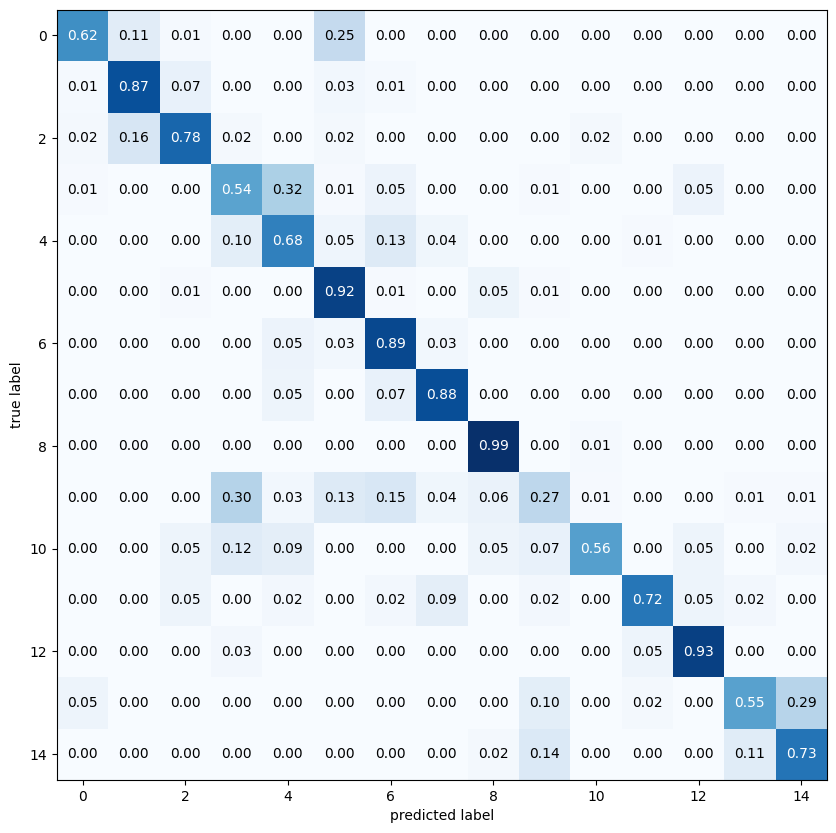

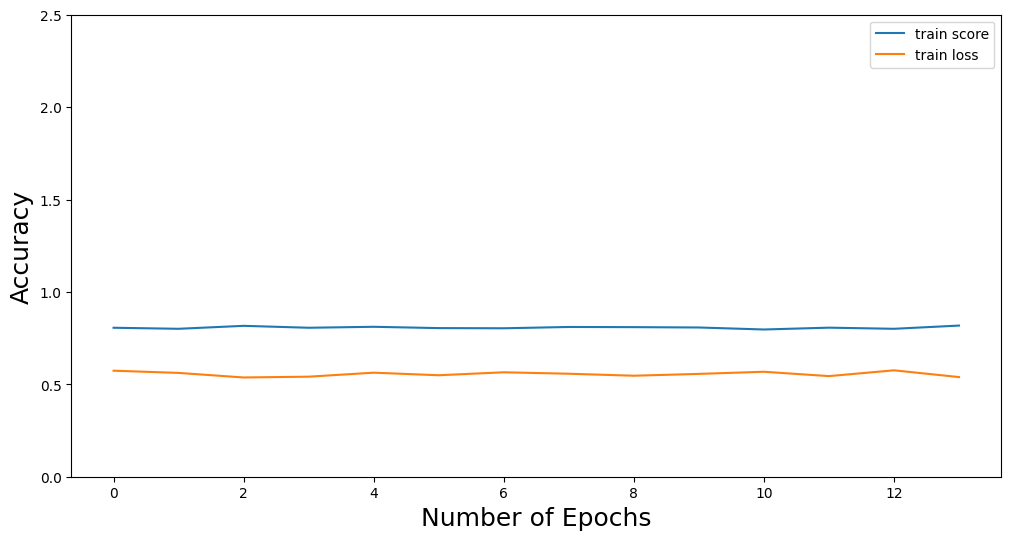

Train Data Shape: (2199, 300, 12)
Test Data Shape: (1132, 300, 12)


Model: "functional_21"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_21      │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_63 (Conv1D)  │ (None, 293, 64)   │      6,208 │ input_layer_21[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_21    │ (None, 31, 64)    │          0 │ conv1d_63[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_105         │ (None, 31, 64)    │          0 │ max_pooling1d_21… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_105[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_21        │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │    134,721 │ time2_vec_21[0][… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_21[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_107         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_107[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_42 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_21[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_64 (Conv1D)  │ (None, 31, 3)     │        198 │ add_42[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_108         │ (None, 31, 3)     │          0 │ conv1d_64[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_65 (Conv1D)  │ (None, 31, 65)    │        260 │ dropout_108[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_65[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_43 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_42[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 65)        │          0 │ add_43[0][0]      │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_42 (Dense)    │ (None, 128)       │      8,448 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_109         │ (None, 128)       │          0 │ dense_42[0][0]    │
│ (Dropout)           │                   │            │                 

 Total params: 152,353 (595.13 KB)

 Trainable params: 152,225 (594.63 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 138ms/step - accuracy: 0.0660 - loss: 2.8238
Epoch 2/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 128ms/step - accuracy: 0.1065 - loss: 2.6737
Epoch 3/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 134ms/step - accuracy: 0.1241 - loss: 2.6202
Epoch 4/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 128ms/step - accuracy: 0.1437 - loss: 2.5626
Epoch 5/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 130ms/step - accuracy: 0.1546 - loss: 2.5143
Epoch 6/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 129ms/step - accuracy: 0.2048 - loss: 2.4459
Epoch 7/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 132ms/step - accuracy: 0.2367 - loss: 2.3443
Epoch 8/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 126ms/step - accuracy: 0.2522 - loss: 2.2882
Epoch 9/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 127ms/step - accuracy: 0.3001 - loss: 2.1256
Epoch 10/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 126ms/step - accuracy: 0.3299 - loss: 2.0364
Epoch 11/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 132ms/step - accuracy: 0.3534 - loss: 1.9097
Epoch 12/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.9729 - loss: 0.1099
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.8253 - loss: 0.5932
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
>#22: 
  train accuracy: 0.96317
  train loss    : 0.12193
  test accuracy: 0.80477
  test loss    : 0.69797

Accuracy: 0.80477 (+/-0.00000)
Loss: 0.69797 (+/-0.00000)


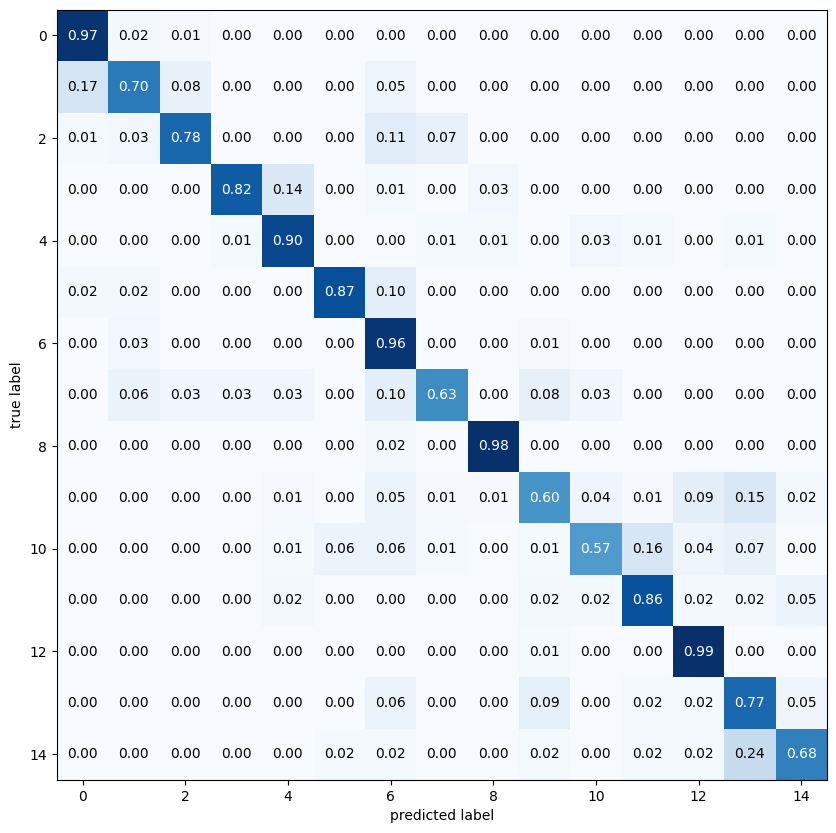

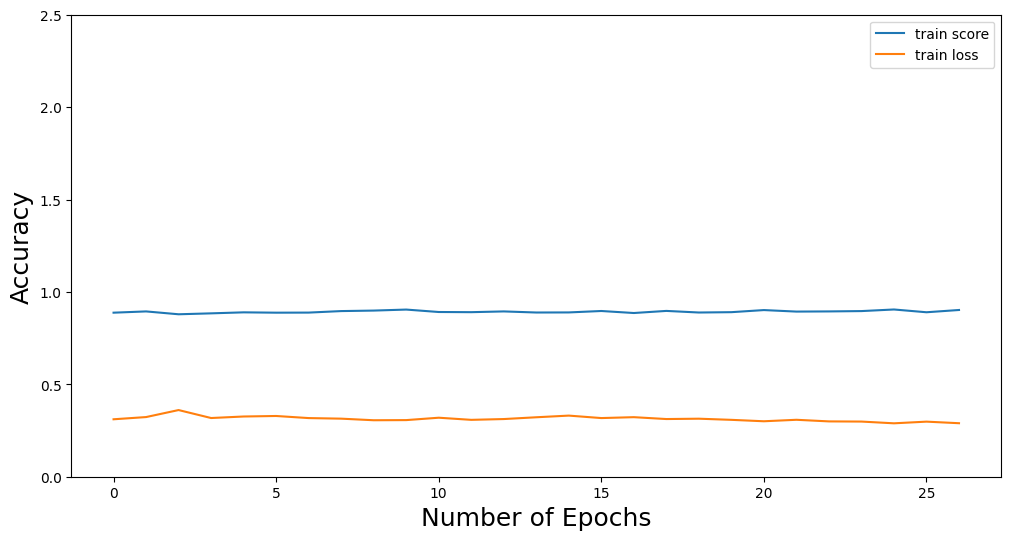

Train Data Shape: (2685, 300, 12)
Test Data Shape: (1334, 300, 12)


Model: "functional_22"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_22      │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_66 (Conv1D)  │ (None, 293, 64)   │      6,208 │ input_layer_22[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_22    │ (None, 31, 64)    │          0 │ conv1d_66[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_110         │ (None, 31, 64)    │          0 │ max_pooling1d_22… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_110[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_22        │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │    134,721 │ time2_vec_22[0][… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_22[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_112         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_112[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_44 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_22[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_67 (Conv1D)  │ (None, 31, 3)     │        198 │ add_44[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_113         │ (None, 31, 3)     │          0 │ conv1d_67[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_68 (Conv1D)  │ (None, 31, 65)    │        260 │ dropout_113[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_68[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_45 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_44[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 65)        │          0 │ add_45[0][0]      │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_44 (Dense)    │ (None, 128)       │      8,448 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_114         │ (None, 128)       │          0 │ dense_44[0][0]    │
│ (Dropout)           │                   │            │                 

 Total params: 152,353 (595.13 KB)

 Trainable params: 152,225 (594.63 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 10s 143ms/step - accuracy: 0.0612 - loss: 2.9515
Epoch 2/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 133ms/step - accuracy: 0.0739 - loss: 2.7160
Epoch 3/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 134ms/step - accuracy: 0.0983 - loss: 2.6561
Epoch 4/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 136ms/step - accuracy: 0.1297 - loss: 2.5887
Epoch 5/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 140ms/step - accuracy: 0.1549 - loss: 2.4729
Epoch 6/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step - accuracy: 0.1912 - loss: 2.3456
Epoch 7/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 134ms/step - accuracy: 0.2373 - loss: 2.2156
Epoch 8/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step - accuracy: 0.2498 - loss: 2.1910
Epoch 9/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 142ms/step - accuracy: 0.2541 - loss: 2.1035
Epoch 10/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 132ms/step - accuracy: 0.3026 - loss: 2.0043
Epoch 11/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 132ms/step - accuracy: 0.3154 - loss: 1.9449
Epoch 12/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 

21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - accuracy: 0.9518 - loss: 0.1816
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.7997 - loss: 0.7026
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step
>#23: 
  train accuracy: 0.94264
  train loss    : 0.20299
  test accuracy: 0.74288
  test loss    : 0.86132

Accuracy: 0.74288 (+/-0.00000)
Loss: 0.86132 (+/-0.00000)


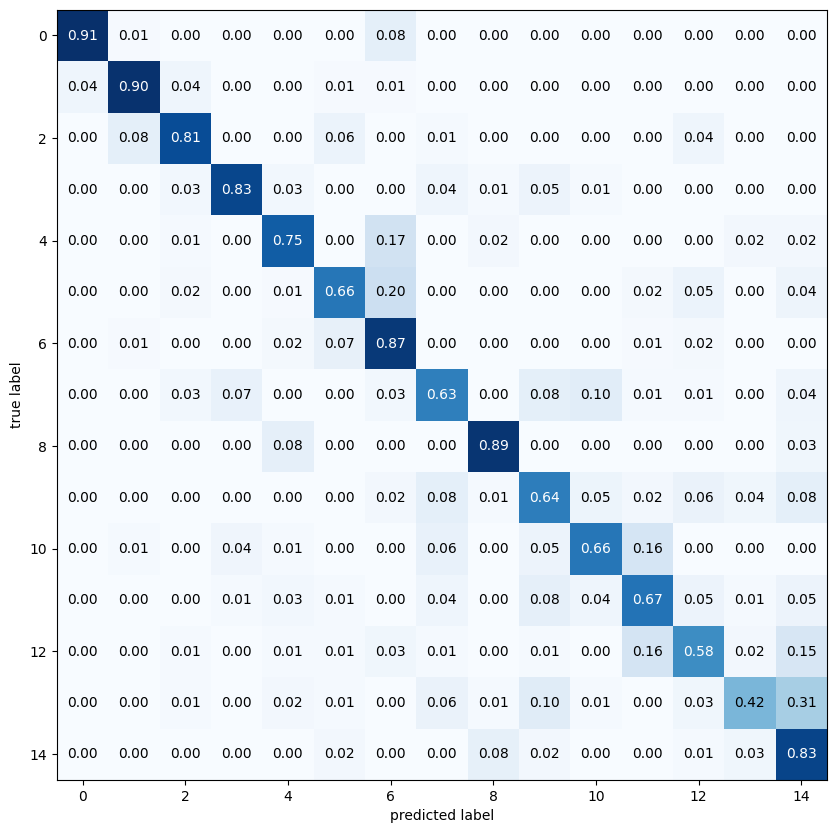

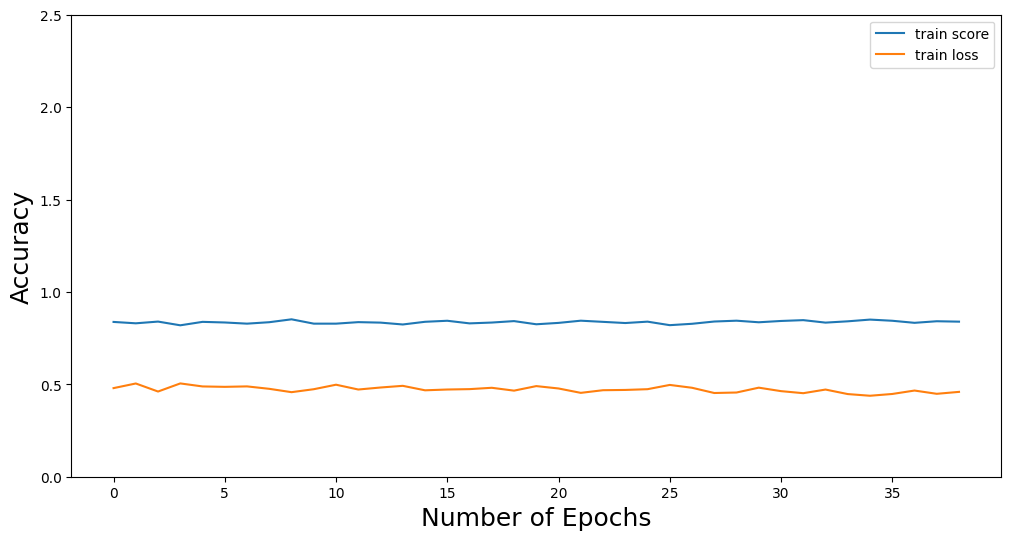

Train Data Shape: (2545, 300, 12)
Test Data Shape: (1270, 300, 12)


Model: "functional_23"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_23      │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_69 (Conv1D)  │ (None, 293, 64)   │      6,208 │ input_layer_23[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_23    │ (None, 31, 64)    │          0 │ conv1d_69[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_115         │ (None, 31, 64)    │          0 │ max_pooling1d_23… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_115[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_23        │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │    134,721 │ time2_vec_23[0][… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_23[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_117         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_117[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_46 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_23[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_70 (Conv1D)  │ (None, 31, 3)     │        198 │ add_46[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_118         │ (None, 31, 3)     │          0 │ conv1d_70[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_71 (Conv1D)  │ (None, 31, 65)    │        260 │ dropout_118[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_71[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_47 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_46[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 65)        │          0 │ add_47[0][0]      │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_46 (Dense)    │ (None, 128)       │      8,448 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_119         │ (None, 128)       │          0 │ dense_46[0][0]    │
│ (Dropout)           │                   │            │                 

 Total params: 152,353 (595.13 KB)

 Trainable params: 152,225 (594.63 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 28s 294ms/step - accuracy: 0.0694 - loss: 2.9076
Epoch 2/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 323ms/step - accuracy: 0.1038 - loss: 2.6902
Epoch 3/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 238ms/step - accuracy: 0.1264 - loss: 2.6410
Epoch 4/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 245ms/step - accuracy: 0.1421 - loss: 2.5624
Epoch 5/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 240ms/step - accuracy: 0.1926 - loss: 2.4496
Epoch 6/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 208ms/step - accuracy: 0.2135 - loss: 2.3448
Epoch 7/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 210ms/step - accuracy: 0.2142 - loss: 2.3237
Epoch 8/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 158ms/step - accuracy: 0.2349 - loss: 2.2201
Epoch 9/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 164ms/step - accuracy: 0.2746 - loss: 2.1182
Epoch 10/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 158ms/step - accuracy: 0.2912 - loss: 2.0588
Epoch 11/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 195ms/step - accuracy: 0.2918 - loss: 2.0133
Epoch 12/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.9065 - loss: 0.2672
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - accuracy: 0.7368 - loss: 0.8585
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step
>#24: 
  train accuracy: 0.88919
  train loss    : 0.33496
  test accuracy: 0.68819
  test loss    : 1.10713

Accuracy: 0.68819 (+/-0.00000)
Loss: 1.10713 (+/-0.00000)


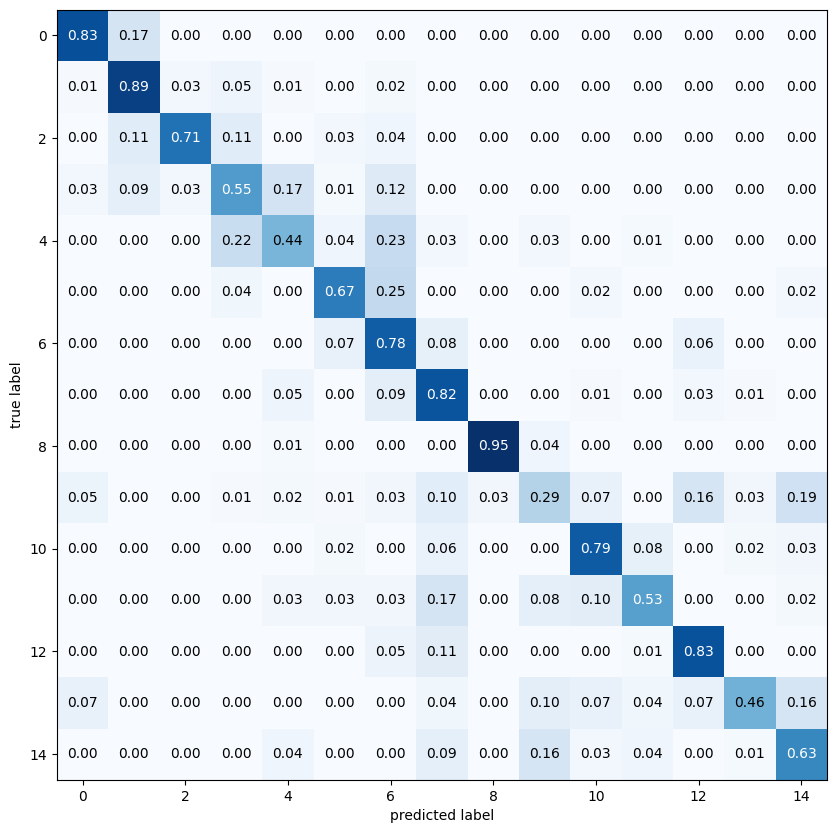

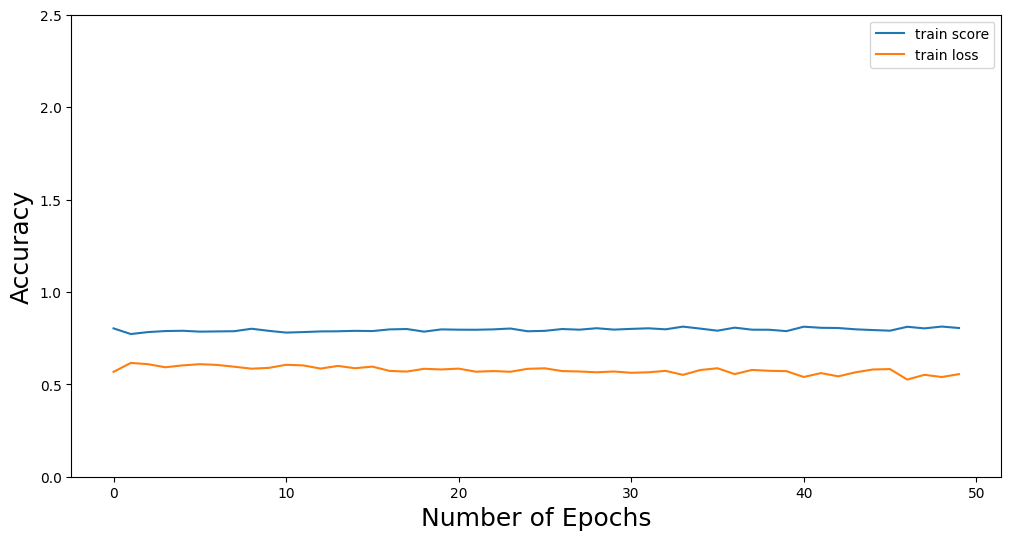

Train Data Shape: (1956, 300, 12)
Test Data Shape: (958, 300, 12)


Model: "functional_24"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_24      │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_72 (Conv1D)  │ (None, 293, 64)   │      6,208 │ input_layer_24[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_24    │ (None, 31, 64)    │          0 │ conv1d_72[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_120         │ (None, 31, 64)    │          0 │ max_pooling1d_24… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_120[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_24        │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │    134,721 │ time2_vec_24[0][… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_24[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_122         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_122[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_48 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_24[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_73 (Conv1D)  │ (None, 31, 3)     │        198 │ add_48[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_123         │ (None, 31, 3)     │          0 │ conv1d_73[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_74 (Conv1D)  │ (None, 31, 65)    │        260 │ dropout_123[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_74[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_49 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_48[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 65)        │          0 │ add_49[0][0]      │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_48 (Dense)    │ (None, 128)       │      8,448 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_124         │ (None, 128)       │          0 │ dense_48[0][0]    │
│ (Dropout)           │                   │            │                 

 Total params: 152,353 (595.13 KB)

 Trainable params: 152,225 (594.63 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 23s 311ms/step - accuracy: 0.1055 - loss: 2.7537
Epoch 2/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 190ms/step - accuracy: 0.1126 - loss: 2.6639
Epoch 3/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 210ms/step - accuracy: 0.1322 - loss: 2.6110
Epoch 4/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 183ms/step - accuracy: 0.1702 - loss: 2.5505
Epoch 5/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 153ms/step - accuracy: 0.1937 - loss: 2.5146
Epoch 6/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 123ms/step - accuracy: 0.2107 - loss: 2.4536
Epoch 7/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 134ms/step - accuracy: 0.2684 - loss: 2.3524
Epoch 8/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 123ms/step - accuracy: 0.2810 - loss: 2.2558
Epoch 9/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 120ms/step - accuracy: 0.2882 - loss: 2.1896
Epoch 10/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 129ms/step - accuracy: 0.2966 - loss: 2.1813
Epoch 11/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 129ms/step - accuracy: 0.3403 - loss: 2.0221
Epoch 12/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - accuracy: 0.9736 - loss: 0.1114
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 154ms/step - accuracy: 0.8838 - loss: 0.4355
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step
>#25: 
  train accuracy: 0.96012
  train loss    : 0.14638
  test accuracy: 0.83925
  test loss    : 0.56423

Accuracy: 0.83925 (+/-0.00000)
Loss: 0.56423 (+/-0.00000)


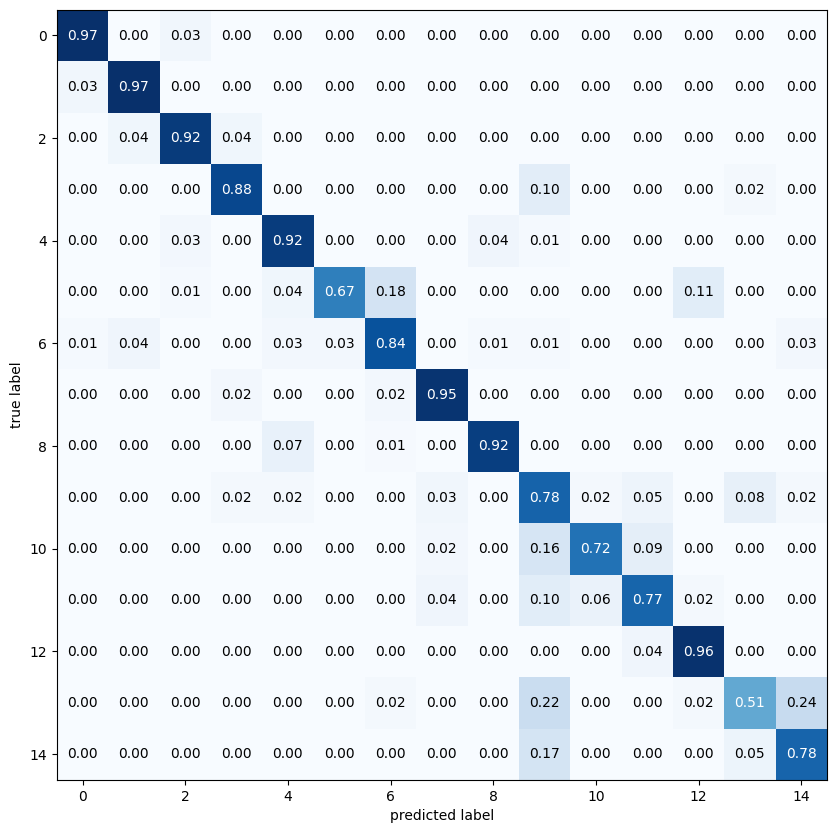

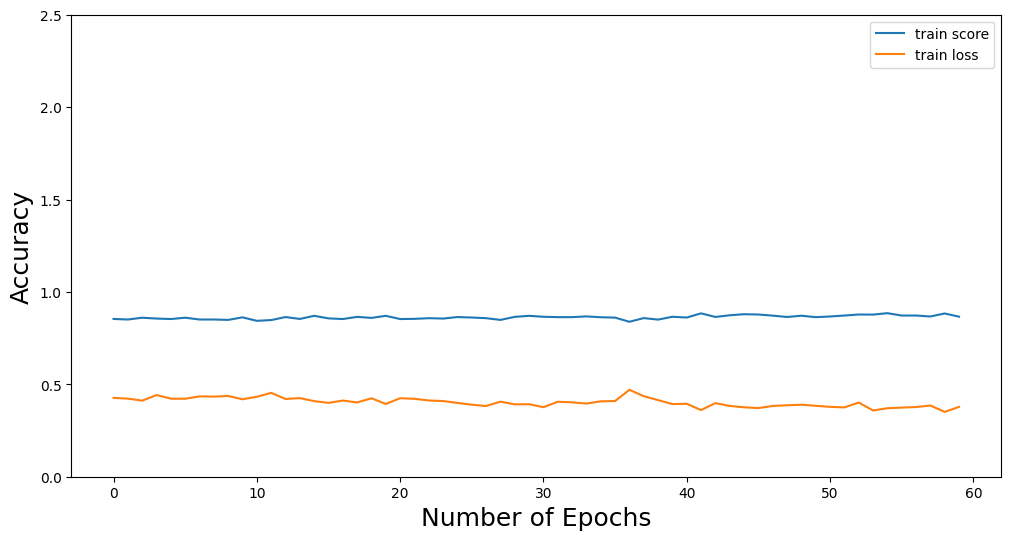

Train Data Shape: (2917, 300, 12)
Test Data Shape: (1473, 300, 12)


Model: "functional_25"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_25      │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_75 (Conv1D)  │ (None, 293, 64)   │      6,208 │ input_layer_25[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_25    │ (None, 31, 64)    │          0 │ conv1d_75[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_125         │ (None, 31, 64)    │          0 │ max_pooling1d_25… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_125[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_25        │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │    134,721 │ time2_vec_25[0][… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_25[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_127         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_127[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_50 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_25[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_76 (Conv1D)  │ (None, 31, 3)     │        198 │ add_50[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_128         │ (None, 31, 3)     │          0 │ conv1d_76[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_77 (Conv1D)  │ (None, 31, 65)    │        260 │ dropout_128[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_77[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_51 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_50[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 65)        │          0 │ add_51[0][0]      │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_50 (Dense)    │ (None, 128)       │      8,448 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_129         │ (None, 128)       │          0 │ dense_50[0][0]    │
│ (Dropout)           │                   │            │                 

 Total params: 152,353 (595.13 KB)

 Trainable params: 152,225 (594.63 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 207ms/step - accuracy: 0.0667 - loss: 2.8620
Epoch 2/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 152ms/step - accuracy: 0.0918 - loss: 2.6875
Epoch 3/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 134ms/step - accuracy: 0.1208 - loss: 2.6298
Epoch 4/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 153ms/step - accuracy: 0.1067 - loss: 2.6308
Epoch 5/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 124ms/step - accuracy: 0.1247 - loss: 2.6025
Epoch 6/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 126ms/step - accuracy: 0.1490 - loss: 2.5624
Epoch 7/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 129ms/step - accuracy: 0.1521 - loss: 2.5369
Epoch 8/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 124ms/step - accuracy: 0.1645 - loss: 2.4953
Epoch 9/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 124ms/step - accuracy: 0.2196 - loss: 2.3645
Epoch 10/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 126ms/step - accuracy: 0.2490 - loss: 2.2488
Epoch 11/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 121ms/step - accuracy: 0.2918 - loss: 2.1439
Epoch 12/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 

23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 114ms/step - accuracy: 0.9510 - loss: 0.1838
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 186ms/step - accuracy: 0.8387 - loss: 0.5489
47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 118ms/step
>#26: 
  train accuracy: 0.93864
  train loss    : 0.21411
  test accuracy: 0.78479
  test loss    : 0.77653

Accuracy: 0.78479 (+/-0.00000)
Loss: 0.77653 (+/-0.00000)


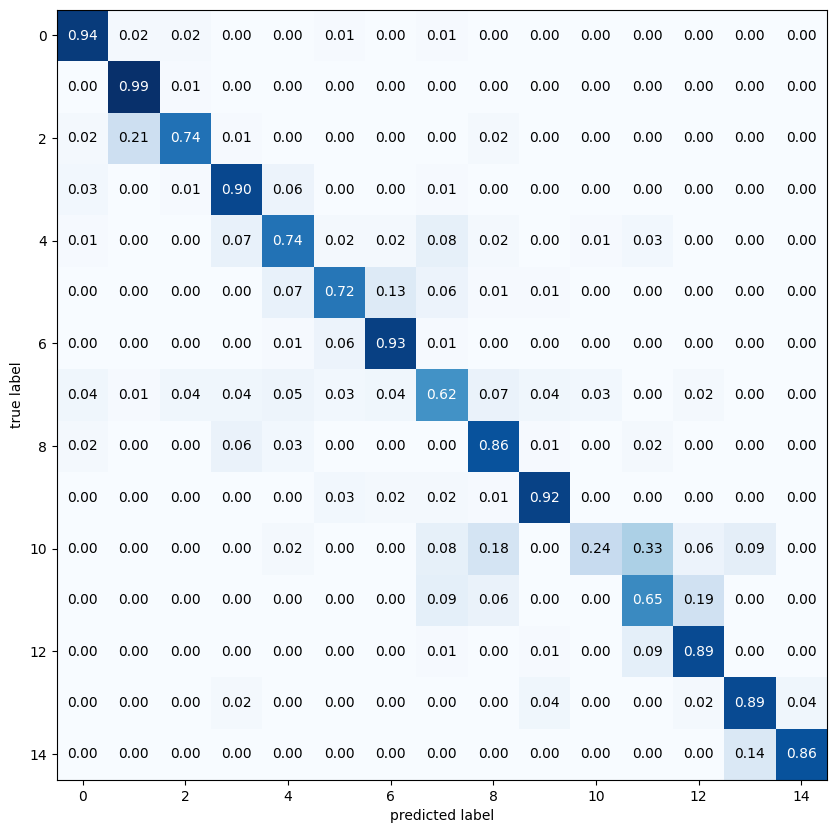

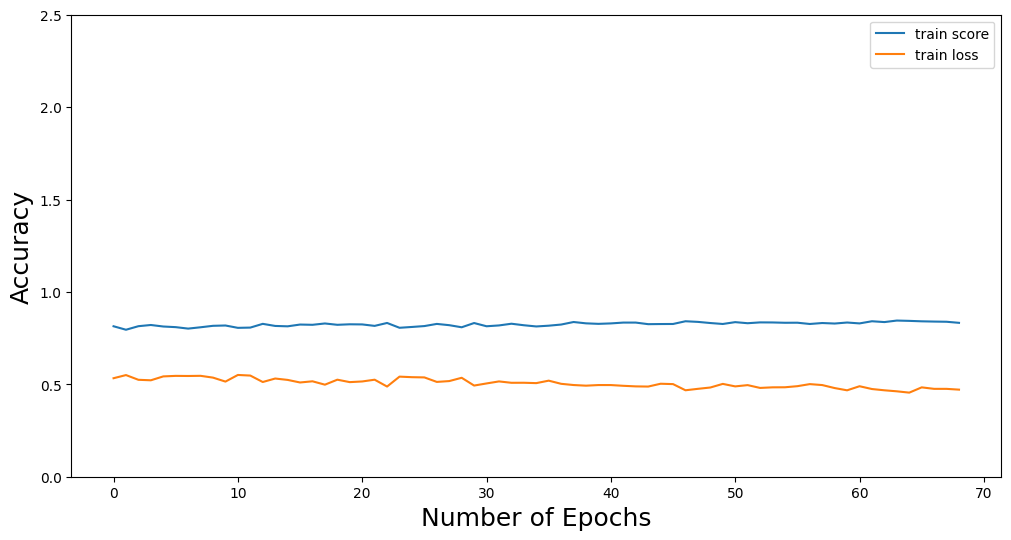

Train Data Shape: (2140, 300, 12)
Test Data Shape: (1070, 300, 12)


Model: "functional_26"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_26      │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_78 (Conv1D)  │ (None, 293, 64)   │      6,208 │ input_layer_26[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_26    │ (None, 31, 64)    │          0 │ conv1d_78[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_130         │ (None, 31, 64)    │          0 │ max_pooling1d_26… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_130[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_26        │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │    134,721 │ time2_vec_26[0][… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_26[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_132         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_132[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_52 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_26[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_79 (Conv1D)  │ (None, 31, 3)     │        198 │ add_52[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_133         │ (None, 31, 3)     │          0 │ conv1d_79[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_80 (Conv1D)  │ (None, 31, 65)    │        260 │ dropout_133[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_80[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_53 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_52[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 65)        │          0 │ add_53[0][0]      │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_52 (Dense)    │ (None, 128)       │      8,448 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_134         │ (None, 128)       │          0 │ dense_52[0][0]    │
│ (Dropout)           │                   │            │                 

 Total params: 152,353 (595.13 KB)

 Trainable params: 152,225 (594.63 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 37s 378ms/step - accuracy: 0.0875 - loss: 2.8813
Epoch 2/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 254ms/step - accuracy: 0.1170 - loss: 2.6507
Epoch 3/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 198ms/step - accuracy: 0.1362 - loss: 2.5816
Epoch 4/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 166ms/step - accuracy: 0.1203 - loss: 2.5782
Epoch 5/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 155ms/step - accuracy: 0.1563 - loss: 2.5118
Epoch 6/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 165ms/step - accuracy: 0.1616 - loss: 2.4495
Epoch 7/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 147ms/step - accuracy: 0.1808 - loss: 2.3886
Epoch 8/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 156ms/step - accuracy: 0.2110 - loss: 2.3506
Epoch 9/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 146ms/step - accuracy: 0.2335 - loss: 2.2756
Epoch 10/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 154ms/step - accuracy: 0.2961 - loss: 2.1664
Epoch 11/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 145ms/step - accuracy: 0.3122 - loss: 2.0960
Epoch 12/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 

17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 116ms/step - accuracy: 0.9715 - loss: 0.1046
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 296ms/step - accuracy: 0.8143 - loss: 0.7709
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step
>#27: 
  train accuracy: 0.96636
  train loss    : 0.11965
  test accuracy: 0.79065
  test loss    : 0.86201

Accuracy: 0.79065 (+/-0.00000)
Loss: 0.86201 (+/-0.00000)


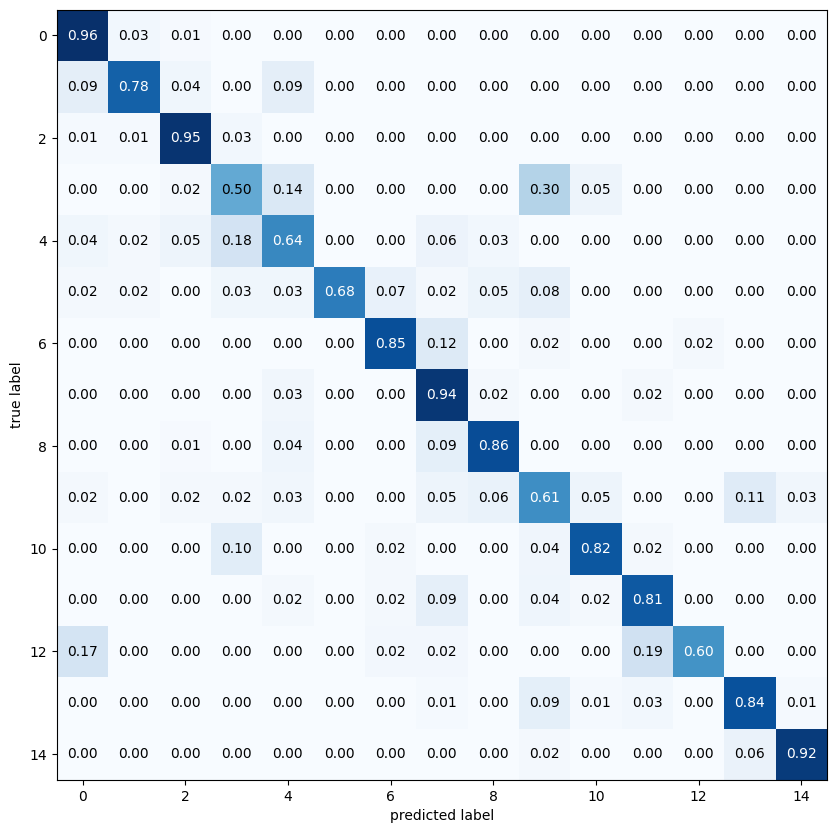

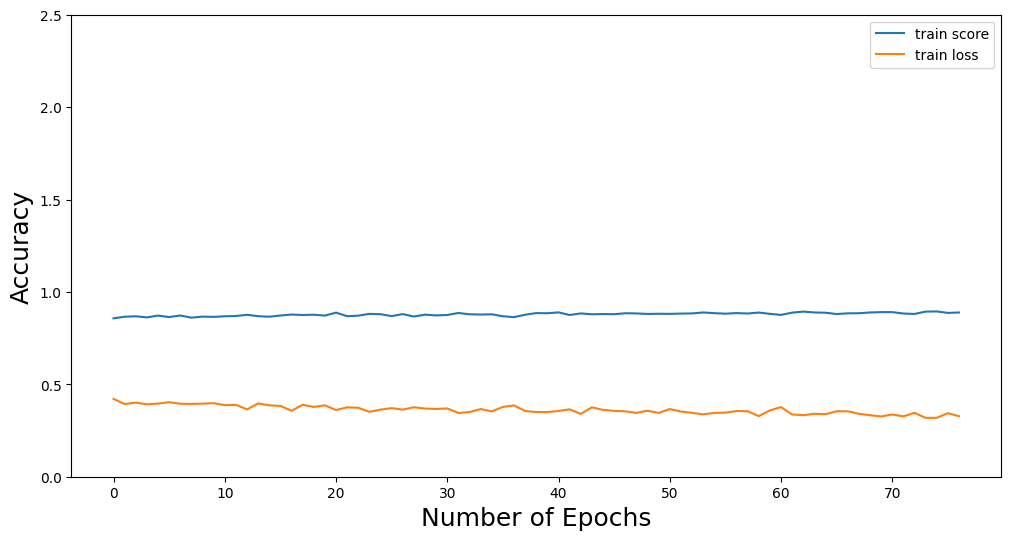

Train Data Shape: (3011, 300, 12)
Test Data Shape: (1424, 300, 12)


Model: "functional_27"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_27      │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_81 (Conv1D)  │ (None, 293, 64)   │      6,208 │ input_layer_27[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_27    │ (None, 31, 64)    │          0 │ conv1d_81[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_135         │ (None, 31, 64)    │          0 │ max_pooling1d_27… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_135[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_27        │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │    134,721 │ time2_vec_27[0][… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_27[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_137         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_137[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_54 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_27[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_82 (Conv1D)  │ (None, 31, 3)     │        198 │ add_54[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_138         │ (None, 31, 3)     │          0 │ conv1d_82[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_83 (Conv1D)  │ (None, 31, 65)    │        260 │ dropout_138[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_83[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_55 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_54[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 65)        │          0 │ add_55[0][0]      │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_54 (Dense)    │ (None, 128)       │      8,448 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_139         │ (None, 128)       │          0 │ dense_54[0][0]    │
│ (Dropout)           │                   │            │                 

 Total params: 152,353 (595.13 KB)

 Trainable params: 152,225 (594.63 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 46s 395ms/step - accuracy: 0.0689 - loss: 2.8697
Epoch 2/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 11s 388ms/step - accuracy: 0.1059 - loss: 2.6642
Epoch 3/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 248ms/step - accuracy: 0.1353 - loss: 2.6061
Epoch 4/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 223ms/step - accuracy: 0.1707 - loss: 2.5007
Epoch 5/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 222ms/step - accuracy: 0.2047 - loss: 2.3766
Epoch 6/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 11s 264ms/step - accuracy: 0.2420 - loss: 2.2755
Epoch 7/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 139ms/step - accuracy: 0.2690 - loss: 2.1836
Epoch 8/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 252ms/step - accuracy: 0.3006 - loss: 2.0961
Epoch 9/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 192ms/step - accuracy: 0.3490 - loss: 2.0147
Epoch 10/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 174ms/step - accuracy: 0.3390 - loss: 1.9624
Epoch 11/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 259ms/step - accuracy: 0.3570 - loss: 1.9378
Epoch 12/300
24/24 ━━━━━━━━━━━━━━━━━━

24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 104ms/step - accuracy: 0.8870 - loss: 0.3567
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 360ms/step - accuracy: 0.6877 - loss: 1.0538
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 102ms/step
>#28: 
  train accuracy: 0.86217
  train loss    : 0.41873
  test accuracy: 0.67346
  test loss    : 1.11856

Accuracy: 0.67346 (+/-0.00000)
Loss: 1.11856 (+/-0.00000)


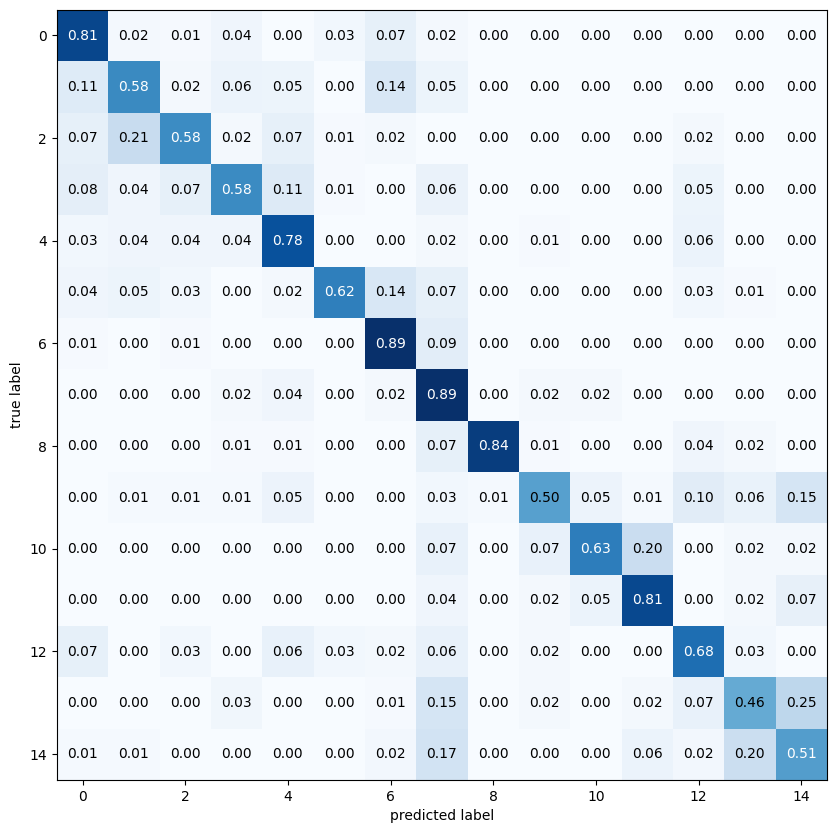

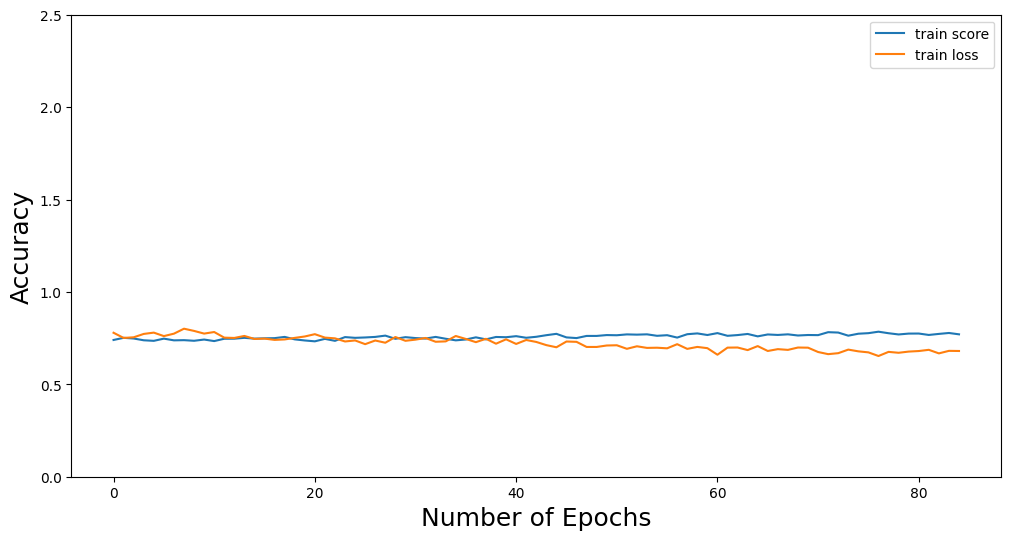

Train Data Shape: (2038, 300, 12)
Test Data Shape: (1055, 300, 12)


Model: "functional_28"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_28      │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_84 (Conv1D)  │ (None, 293, 64)   │      6,208 │ input_layer_28[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_28    │ (None, 31, 64)    │          0 │ conv1d_84[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_140         │ (None, 31, 64)    │          0 │ max_pooling1d_28… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_140[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_28        │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │    134,721 │ time2_vec_28[0][… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_28[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_142         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_142[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_56 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_28[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_85 (Conv1D)  │ (None, 31, 3)     │        198 │ add_56[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_143         │ (None, 31, 3)     │          0 │ conv1d_85[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_86 (Conv1D)  │ (None, 31, 65)    │        260 │ dropout_143[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_86[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_57 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_56[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 65)        │          0 │ add_57[0][0]      │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_56 (Dense)    │ (None, 128)       │      8,448 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_144         │ (None, 128)       │          0 │ dense_56[0][0]    │
│ (Dropout)           │                   │            │                 

 Total params: 152,353 (595.13 KB)

 Trainable params: 152,225 (594.63 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 36s 447ms/step - accuracy: 0.0807 - loss: 2.8287
Epoch 2/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 331ms/step - accuracy: 0.1243 - loss: 2.6377
Epoch 3/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 297ms/step - accuracy: 0.1467 - loss: 2.5521
Epoch 4/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 262ms/step - accuracy: 0.1383 - loss: 2.5362
Epoch 5/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 304ms/step - accuracy: 0.1516 - loss: 2.4964
Epoch 6/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 201ms/step - accuracy: 0.1532 - loss: 2.4734
Epoch 7/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 202ms/step - accuracy: 0.1599 - loss: 2.4129
Epoch 8/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 163ms/step - accuracy: 0.1823 - loss: 2.3808
Epoch 9/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 204ms/step - accuracy: 0.1680 - loss: 2.3609
Epoch 10/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 161ms/step - accuracy: 0.2171 - loss: 2.2865
Epoch 11/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 181ms/step - accuracy: 0.2426 - loss: 2.2400
Epoch 12/300
16/16 ━━━━━━━━━━━━━━━━━━━━

16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - accuracy: 0.9749 - loss: 0.1150
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 298ms/step - accuracy: 0.7613 - loss: 0.8287
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step
>#29: 
  train accuracy: 0.96516
  train loss    : 0.13119
  test accuracy: 0.73649
  test loss    : 0.94669

Accuracy: 0.73649 (+/-0.00000)
Loss: 0.94669 (+/-0.00000)


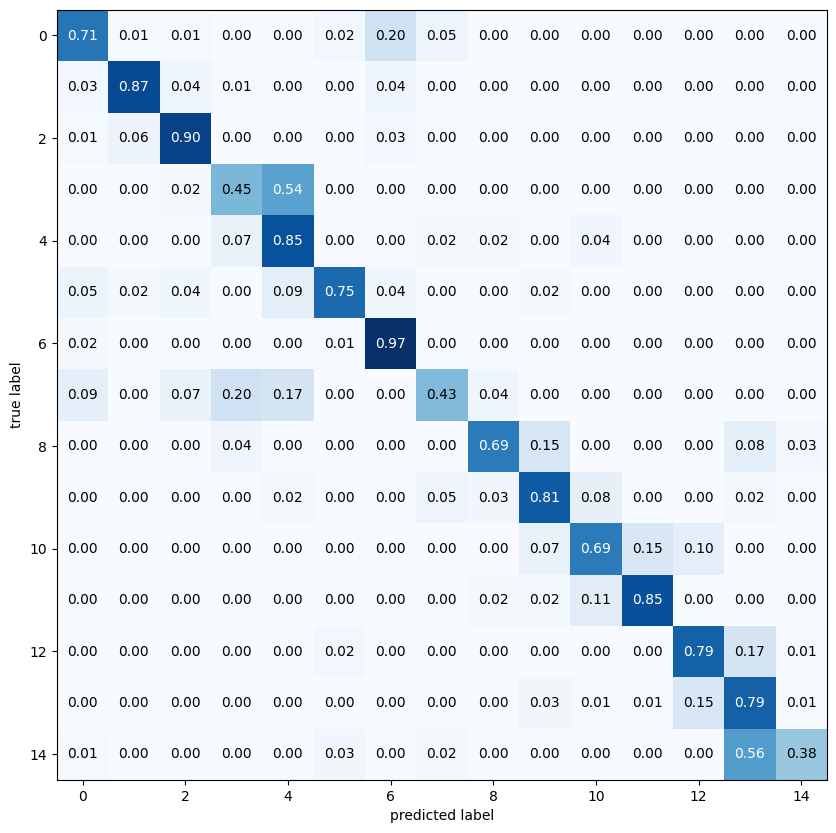

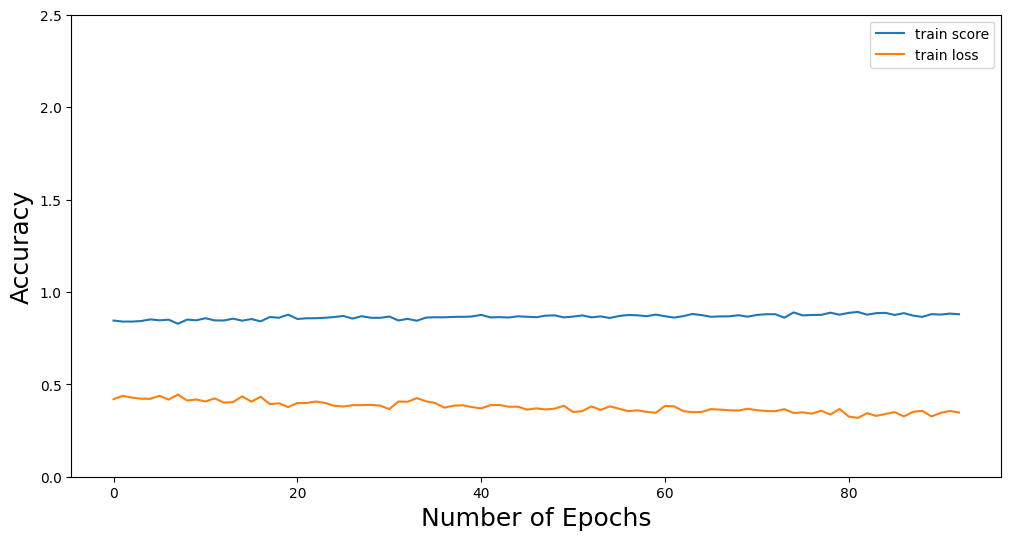

Train Data Shape: (2752, 300, 12)
Test Data Shape: (1415, 300, 12)


Model: "functional_29"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_29      │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_87 (Conv1D)  │ (None, 293, 64)   │      6,208 │ input_layer_29[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_29    │ (None, 31, 64)    │          0 │ conv1d_87[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_145         │ (None, 31, 64)    │          0 │ max_pooling1d_29… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_145[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_29        │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │    134,721 │ time2_vec_29[0][… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_29[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_147         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_147[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_58 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_29[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_88 (Conv1D)  │ (None, 31, 3)     │        198 │ add_58[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_148         │ (None, 31, 3)     │          0 │ conv1d_88[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_89 (Conv1D)  │ (None, 31, 65)    │        260 │ dropout_148[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_89[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_59 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_58[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 65)        │          0 │ add_59[0][0]      │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_58 (Dense)    │ (None, 128)       │      8,448 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_149         │ (None, 128)       │          0 │ dense_58[0][0]    │
│ (Dropout)           │                   │            │                 

 Total params: 152,353 (595.13 KB)

 Trainable params: 152,225 (594.63 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/300
22/22 ━━━━━━━━━━━━━━━━━━━━ 14s 246ms/step - accuracy: 0.1048 - loss: 2.7636
Epoch 2/300
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 186ms/step - accuracy: 0.1617 - loss: 2.5149
Epoch 3/300
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 157ms/step - accuracy: 0.1832 - loss: 2.4250
Epoch 4/300
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 179ms/step - accuracy: 0.2678 - loss: 2.2462
Epoch 5/300
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 153ms/step - accuracy: 0.3019 - loss: 2.1355
Epoch 6/300
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 143ms/step - accuracy: 0.3674 - loss: 1.9471
Epoch 7/300
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 132ms/step - accuracy: 0.3807 - loss: 1.8160
Epoch 8/300
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 136ms/step - accuracy: 0.3839 - loss: 1.7915
Epoch 9/300
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 134ms/step - accuracy: 0.4397 - loss: 1.6568
Epoch 10/300
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 133ms/step - accuracy: 0.4535 - loss: 1.5964
Epoch 11/300
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 131ms/step - accuracy: 0.4918 - loss: 1.4897
Epoch 12/300
22/22 ━━━━━━━━━━━━━━━━━━━━ 

22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - accuracy: 0.8865 - loss: 0.3098
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 354ms/step - accuracy: 0.7316 - loss: 0.8322
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step
>#30: 
  train accuracy: 0.89971
  train loss    : 0.28456
  test accuracy: 0.72862
  test loss    : 0.81575

Accuracy: 0.72862 (+/-0.00000)
Loss: 0.81575 (+/-0.00000)


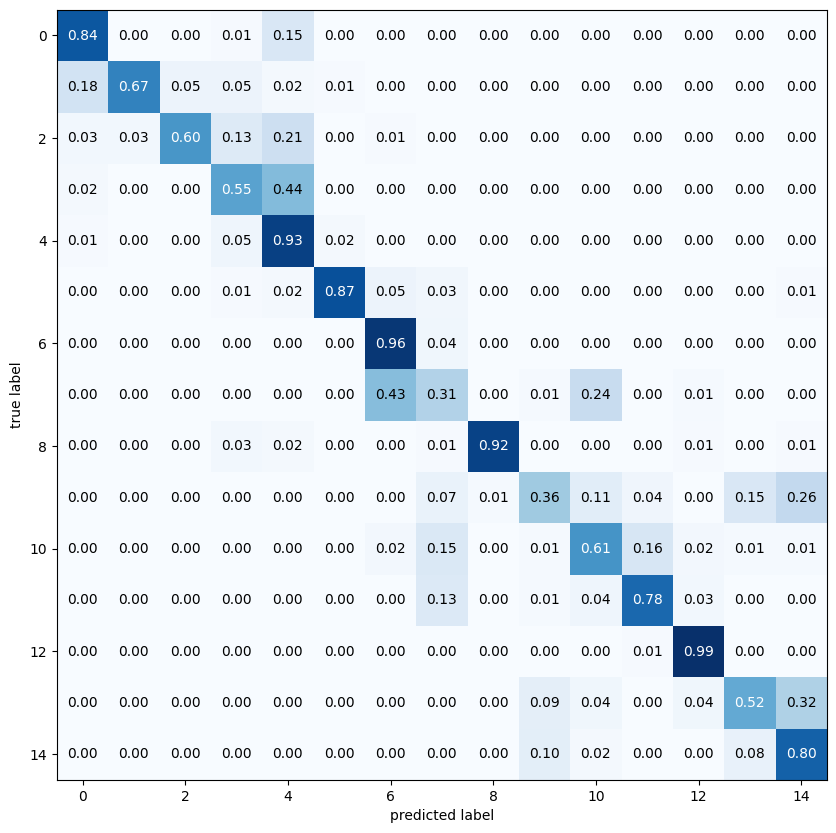

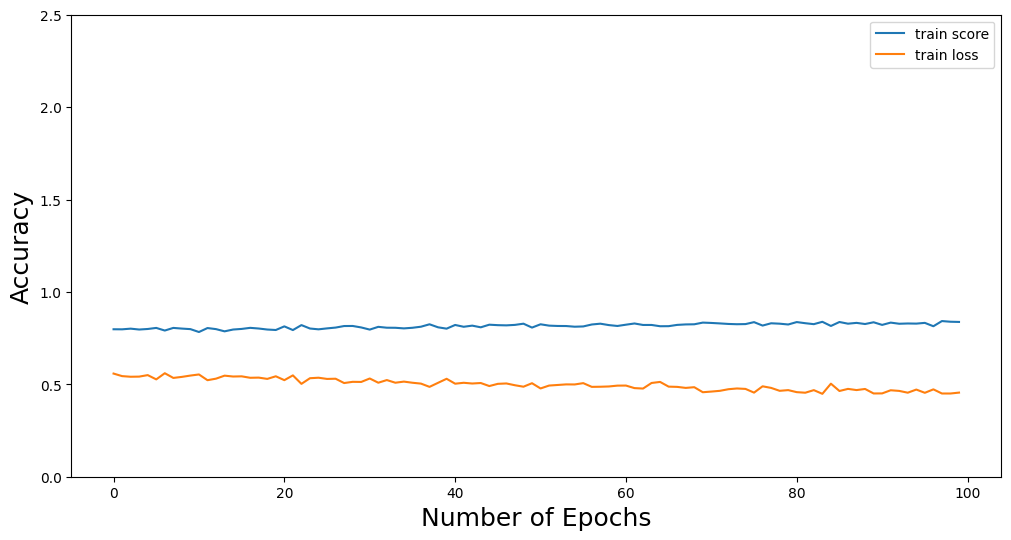

Train Data Shape: (2848, 300, 12)
Test Data Shape: (1426, 300, 12)


Model: "functional_30"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_30      │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_90 (Conv1D)  │ (None, 293, 64)   │      6,208 │ input_layer_30[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_30    │ (None, 31, 64)    │          0 │ conv1d_90[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_150         │ (None, 31, 64)    │          0 │ max_pooling1d_30… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_150[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_30        │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │    134,721 │ time2_vec_30[0][… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_30[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_152         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_152[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_60 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_30[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_91 (Conv1D)  │ (None, 31, 3)     │        198 │ add_60[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_153         │ (None, 31, 3)     │          0 │ conv1d_91[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_92 (Conv1D)  │ (None, 31, 65)    │        260 │ dropout_153[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_92[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_61 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_60[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 65)        │          0 │ add_61[0][0]      │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_60 (Dense)    │ (None, 128)       │      8,448 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_154         │ (None, 128)       │          0 │ dense_60[0][0]    │
│ (Dropout)           │                   │            │                 

 Total params: 152,353 (595.13 KB)

 Trainable params: 152,225 (594.63 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 26s 349ms/step - accuracy: 0.0894 - loss: 2.8623
Epoch 2/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 280ms/step - accuracy: 0.0950 - loss: 2.6563
Epoch 3/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 175ms/step - accuracy: 0.1182 - loss: 2.5974
Epoch 4/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 302ms/step - accuracy: 0.1389 - loss: 2.5743
Epoch 5/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 270ms/step - accuracy: 0.1550 - loss: 2.5140
Epoch 6/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 204ms/step - accuracy: 0.1781 - loss: 2.4645
Epoch 7/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 269ms/step - accuracy: 0.1970 - loss: 2.4284
Epoch 8/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 211ms/step - accuracy: 0.2263 - loss: 2.3379
Epoch 9/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 286ms/step - accuracy: 0.2606 - loss: 2.2723
Epoch 10/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 259ms/step - accuracy: 0.2659 - loss: 2.2272
Epoch 11/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 144ms/step - accuracy: 0.2909 - loss: 2.1681
Epoch 12/300
23/23 ━━━━━━━━━━━━━━━━━━━

23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.9344 - loss: 0.2312
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 232ms/step - accuracy: 0.7783 - loss: 0.7179
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step
>#31: 
  train accuracy: 0.90906
  train loss    : 0.29896
  test accuracy: 0.72931
  test loss    : 0.85958

Accuracy: 0.72931 (+/-0.00000)
Loss: 0.85958 (+/-0.00000)


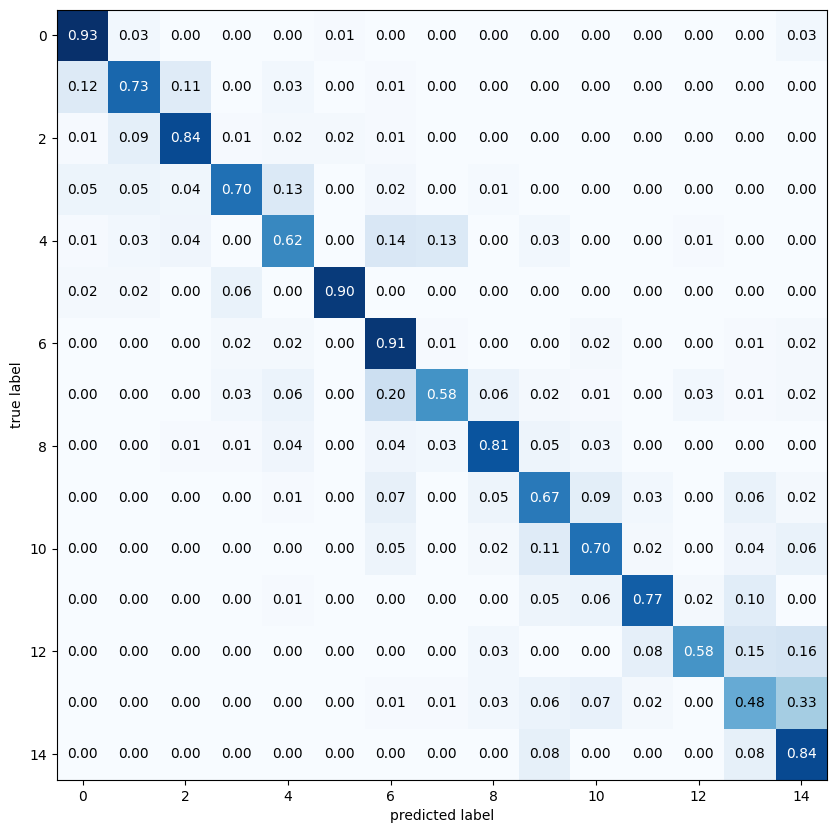

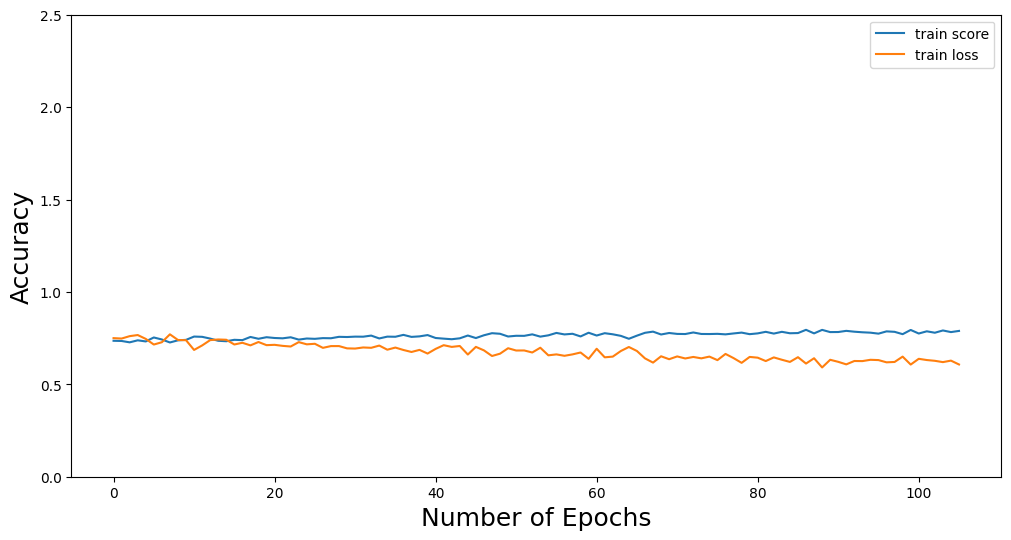

Train Data Shape: (2325, 300, 12)
Test Data Shape: (1115, 300, 12)


Model: "functional_31"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_31      │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_93 (Conv1D)  │ (None, 293, 64)   │      6,208 │ input_layer_31[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_31    │ (None, 31, 64)    │          0 │ conv1d_93[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_155         │ (None, 31, 64)    │          0 │ max_pooling1d_31… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_155[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_31        │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │    134,721 │ time2_vec_31[0][… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_31[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_157         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_157[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_62 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_31[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_94 (Conv1D)  │ (None, 31, 3)     │        198 │ add_62[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_158         │ (None, 31, 3)     │          0 │ conv1d_94[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_95 (Conv1D)  │ (None, 31, 65)    │        260 │ dropout_158[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_95[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_63 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_62[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 65)        │          0 │ add_63[0][0]      │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_62 (Dense)    │ (None, 128)       │      8,448 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_159         │ (None, 128)       │          0 │ dense_62[0][0]    │
│ (Dropout)           │                   │            │                 

 Total params: 152,353 (595.13 KB)

 Trainable params: 152,225 (594.63 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/300
19/19 ━━━━━━━━━━━━━━━━━━━━ 33s 355ms/step - accuracy: 0.0852 - loss: 2.8139
Epoch 2/300
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 301ms/step - accuracy: 0.1265 - loss: 2.6203
Epoch 3/300
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 212ms/step - accuracy: 0.1576 - loss: 2.5234
Epoch 4/300
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 319ms/step - accuracy: 0.1865 - loss: 2.4577
Epoch 5/300
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 291ms/step - accuracy: 0.2452 - loss: 2.3290
Epoch 6/300
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 261ms/step - accuracy: 0.2667 - loss: 2.2781
Epoch 7/300
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 272ms/step - accuracy: 0.2765 - loss: 2.2284
Epoch 8/300
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 223ms/step - accuracy: 0.3321 - loss: 2.0821
Epoch 9/300
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 225ms/step - accuracy: 0.3356 - loss: 2.0462
Epoch 10/300
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 300ms/step - accuracy: 0.3838 - loss: 1.8947
Epoch 11/300
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 143ms/step - accuracy: 0.3738 - loss: 1.8812
Epoch 12/300
19/19 ━━━━━━━━━━━━━━━━━━

19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.9190 - loss: 0.2359
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 299ms/step - accuracy: 0.7765 - loss: 0.7162
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 105ms/step
>#32: 
  train accuracy: 0.90151
  train loss    : 0.29333
  test accuracy: 0.77040
  test loss    : 0.71937

Accuracy: 0.77040 (+/-0.00000)
Loss: 0.71937 (+/-0.00000)


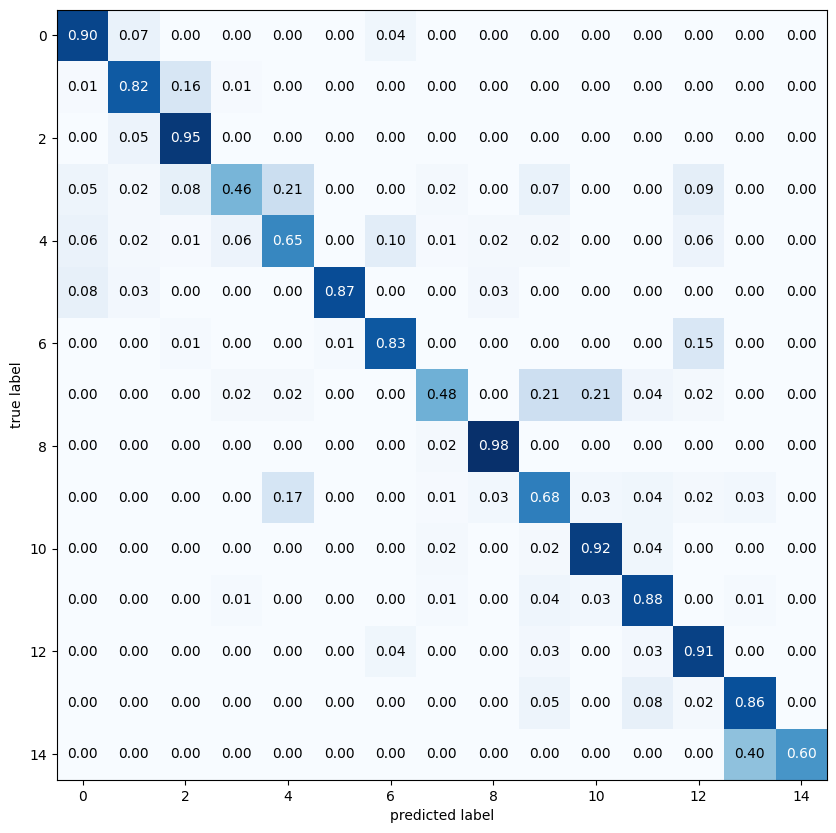

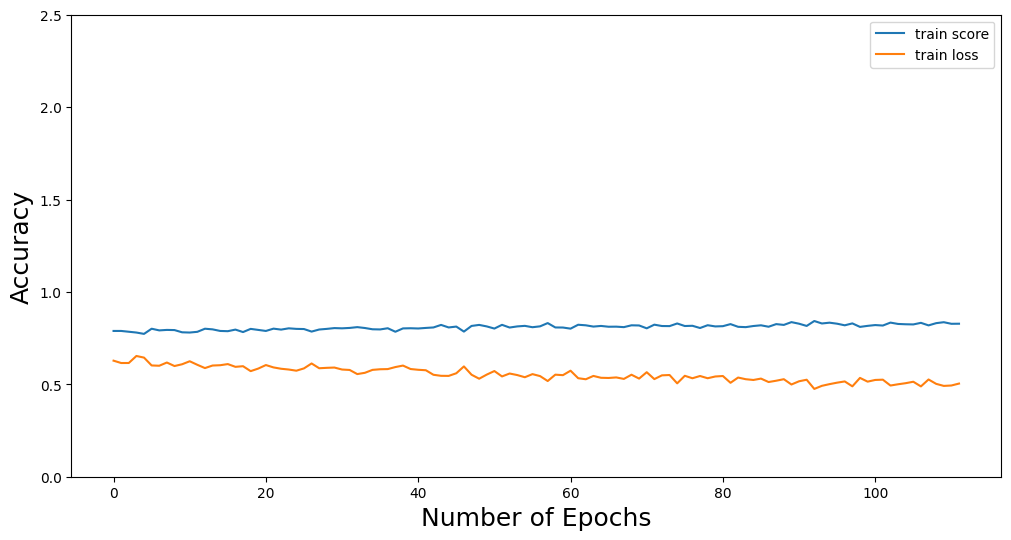

Train Data Shape: (2595, 300, 12)
Test Data Shape: (1243, 300, 12)


Model: "functional_32"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_32      │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_96 (Conv1D)  │ (None, 293, 64)   │      6,208 │ input_layer_32[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_32    │ (None, 31, 64)    │          0 │ conv1d_96[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_160         │ (None, 31, 64)    │          0 │ max_pooling1d_32… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_160[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_32        │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │    134,721 │ time2_vec_32[0][… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_32[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_162         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_162[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_64 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_32[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_97 (Conv1D)  │ (None, 31, 3)     │        198 │ add_64[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_163         │ (None, 31, 3)     │          0 │ conv1d_97[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_98 (Conv1D)  │ (None, 31, 65)    │        260 │ dropout_163[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_98[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_65 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_64[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 65)        │          0 │ add_65[0][0]      │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_64 (Dense)    │ (None, 128)       │      8,448 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_164         │ (None, 128)       │          0 │ dense_64[0][0]    │
│ (Dropout)           │                   │            │                 

 Total params: 152,353 (595.13 KB)

 Trainable params: 152,225 (594.63 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 31s 282ms/step - accuracy: 0.1143 - loss: 2.8184
Epoch 2/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 10s 250ms/step - accuracy: 0.1713 - loss: 2.5579
Epoch 3/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 188ms/step - accuracy: 0.2034 - loss: 2.4618
Epoch 4/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 200ms/step - accuracy: 0.2679 - loss: 2.3112
Epoch 5/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 172ms/step - accuracy: 0.3405 - loss: 2.1265
Epoch 6/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 155ms/step - accuracy: 0.3613 - loss: 1.9598
Epoch 7/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 298ms/step - accuracy: 0.3916 - loss: 1.8680
Epoch 8/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 238ms/step - accuracy: 0.4635 - loss: 1.6714
Epoch 9/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 331ms/step - accuracy: 0.4958 - loss: 1.5762
Epoch 10/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 215ms/step - accuracy: 0.5101 - loss: 1.5099
Epoch 11/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 303ms/step - accuracy: 0.5168 - loss: 1.4461
Epoch 12/300
21/21 ━━━━━━━━━━━━━━━━━━━━

21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 128ms/step - accuracy: 0.9789 - loss: 0.0798
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 189ms/step - accuracy: 0.9250 - loss: 0.2466
39/39 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step
>#33: 
  train accuracy: 0.96763
  train loss    : 0.10968
  test accuracy: 0.88093
  test loss    : 0.36614

Accuracy: 0.88093 (+/-0.00000)
Loss: 0.36614 (+/-0.00000)


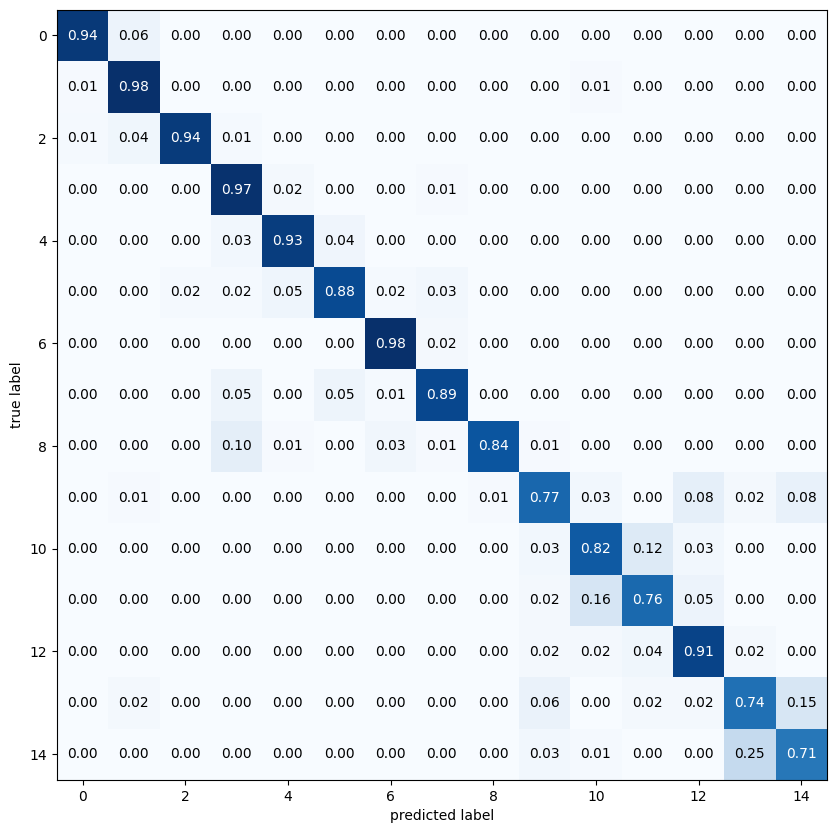

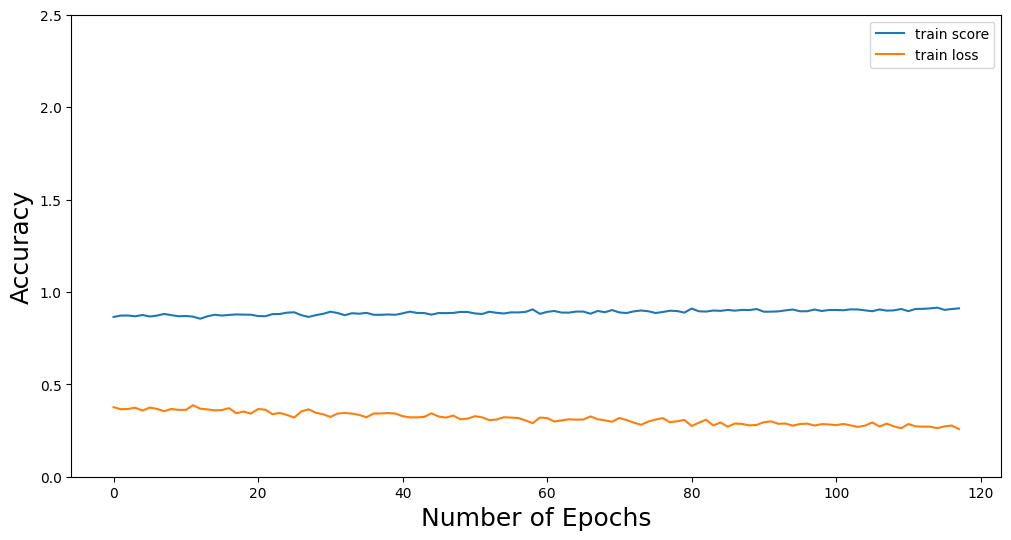

Train Data Shape: (2515, 300, 12)
Test Data Shape: (1265, 300, 12)


Model: "functional_33"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_33      │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_99 (Conv1D)  │ (None, 293, 64)   │      6,208 │ input_layer_33[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_33    │ (None, 31, 64)    │          0 │ conv1d_99[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_165         │ (None, 31, 64)    │          0 │ max_pooling1d_33… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_165[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_33        │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │    134,721 │ time2_vec_33[0][… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_33[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_167         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_167[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_66 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_33[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_100 (Conv1D) │ (None, 31, 3)     │        198 │ add_66[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_168         │ (None, 31, 3)     │          0 │ conv1d_100[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_101 (Conv1D) │ (None, 31, 65)    │        260 │ dropout_168[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_101[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_67 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_66[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 65)        │          0 │ add_67[0][0]      │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_66 (Dense)    │ (None, 128)       │      8,448 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_169         │ (None, 128)       │          0 │ dense_66[0][0]    │
│ (Dropout)           │                   │            │                 

 Total params: 152,353 (595.13 KB)

 Trainable params: 152,225 (594.63 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 36s 356ms/step - accuracy: 0.0892 - loss: 2.7928
Epoch 2/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 346ms/step - accuracy: 0.1405 - loss: 2.5726
Epoch 3/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 326ms/step - accuracy: 0.1809 - loss: 2.4328
Epoch 4/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 305ms/step - accuracy: 0.2296 - loss: 2.2994
Epoch 5/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 211ms/step - accuracy: 0.2351 - loss: 2.2215
Epoch 6/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 280ms/step - accuracy: 0.3024 - loss: 2.1189
Epoch 7/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 282ms/step - accuracy: 0.3134 - loss: 2.0158
Epoch 8/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 195ms/step - accuracy: 0.3417 - loss: 1.8947
Epoch 9/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 262ms/step - accuracy: 0.3588 - loss: 1.8511
Epoch 10/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 139ms/step - accuracy: 0.3915 - loss: 1.7083
Epoch 11/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 250ms/step - accuracy: 0.4478 - loss: 1.5703
Epoch 12/300
20/20 ━━━━━━━━━━━━━━━━━━━

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.9831 - loss: 0.0659
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 239ms/step - accuracy: 0.8102 - loss: 0.6421
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step
>#34: 
  train accuracy: 0.97893
  train loss    : 0.08689
  test accuracy: 0.78656
  test loss    : 0.79059

Accuracy: 0.78656 (+/-0.00000)
Loss: 0.79059 (+/-0.00000)


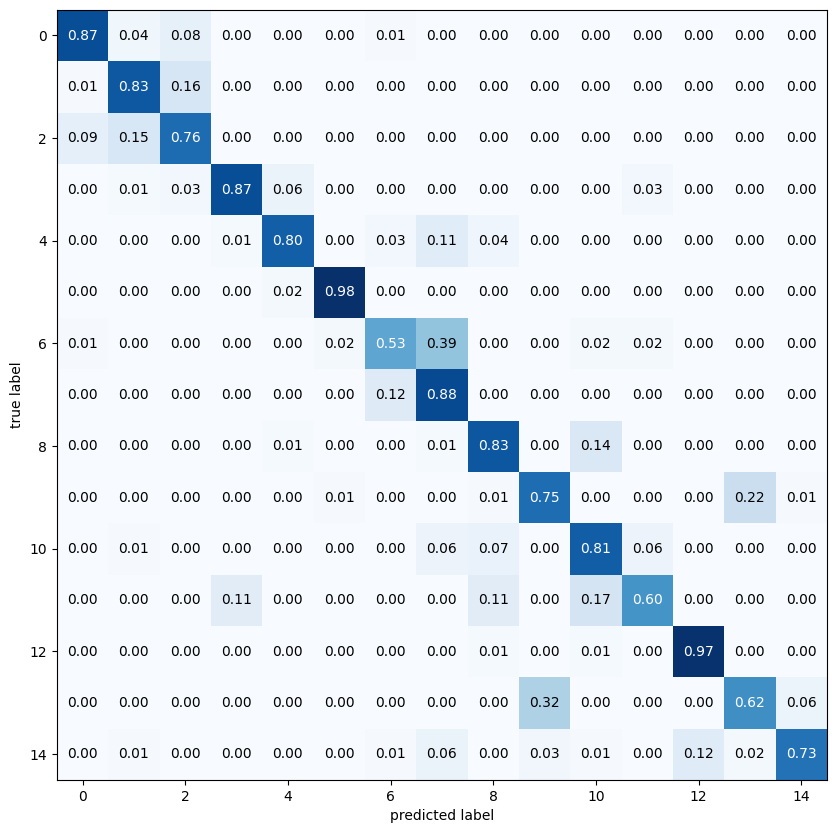

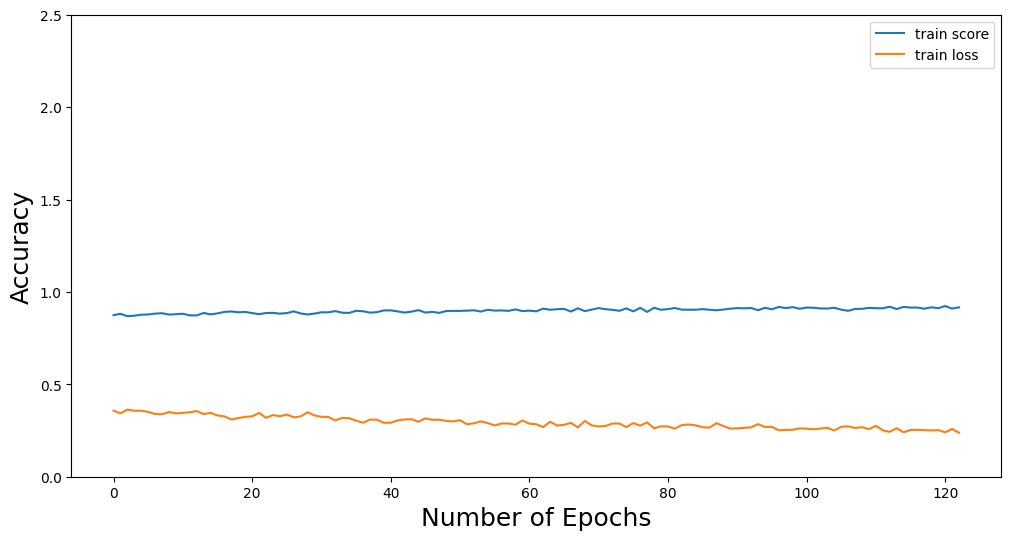

Train Data Shape: (3073, 300, 12)
Test Data Shape: (1536, 300, 12)


Model: "functional_34"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_34      │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_102 (Conv1D) │ (None, 293, 64)   │      6,208 │ input_layer_34[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_34    │ (None, 31, 64)    │          0 │ conv1d_102[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_170         │ (None, 31, 64)    │          0 │ max_pooling1d_34… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_170[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_34        │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │    134,721 │ time2_vec_34[0][… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_34[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_172         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_172[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_68 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_34[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_103 (Conv1D) │ (None, 31, 3)     │        198 │ add_68[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_173         │ (None, 31, 3)     │          0 │ conv1d_103[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_104 (Conv1D) │ (None, 31, 65)    │        260 │ dropout_173[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_104[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_69 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_68[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 65)        │          0 │ add_69[0][0]      │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_68 (Dense)    │ (None, 128)       │      8,448 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_174         │ (None, 128)       │          0 │ dense_68[0][0]    │
│ (Dropout)           │                   │            │                 

 Total params: 152,353 (595.13 KB)

 Trainable params: 152,225 (594.63 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 25s 218ms/step - accuracy: 0.0862 - loss: 2.8142
Epoch 2/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 172ms/step - accuracy: 0.1371 - loss: 2.6043
Epoch 3/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 151ms/step - accuracy: 0.1603 - loss: 2.5567
Epoch 4/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 143ms/step - accuracy: 0.1873 - loss: 2.4458
Epoch 5/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 147ms/step - accuracy: 0.2379 - loss: 2.3589
Epoch 6/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 139ms/step - accuracy: 0.2639 - loss: 2.2846
Epoch 7/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 141ms/step - accuracy: 0.2661 - loss: 2.2191
Epoch 8/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 147ms/step - accuracy: 0.3045 - loss: 2.1904
Epoch 9/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 143ms/step - accuracy: 0.3076 - loss: 2.1366
Epoch 10/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 133ms/step - accuracy: 0.3278 - loss: 2.0966
Epoch 11/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 134ms/step - accuracy: 0.3604 - loss: 2.0240
Epoch 12/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 

25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.8637 - loss: 0.3977
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.7655 - loss: 0.6969
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
>#35: 
  train accuracy: 0.83567
  train loss    : 0.46014
  test accuracy: 0.72721
  test loss    : 0.81181

Accuracy: 0.72721 (+/-0.00000)
Loss: 0.81181 (+/-0.00000)


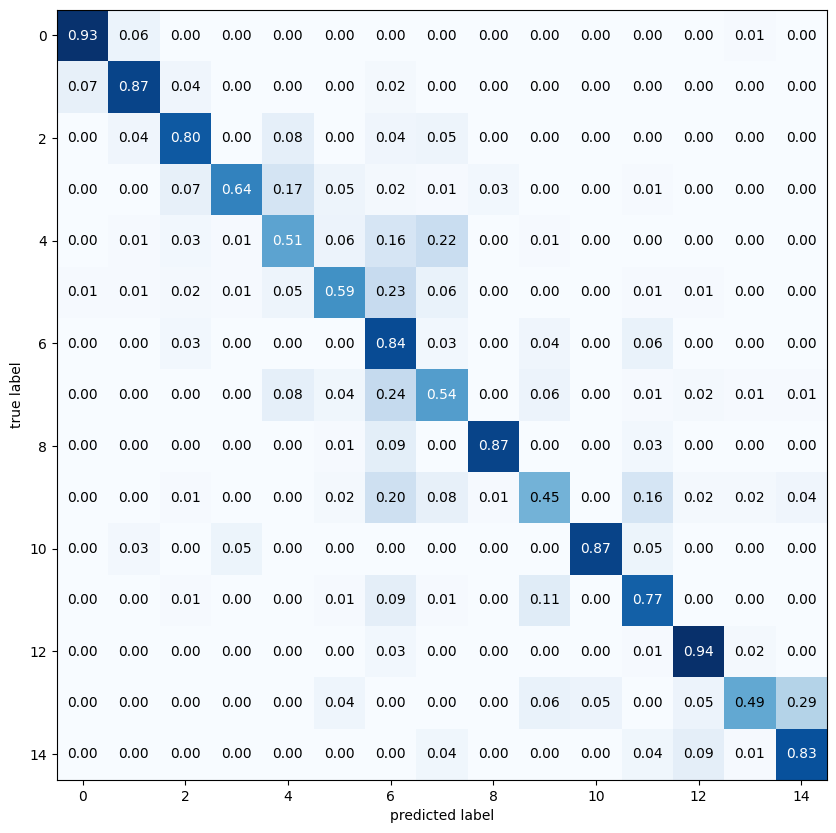

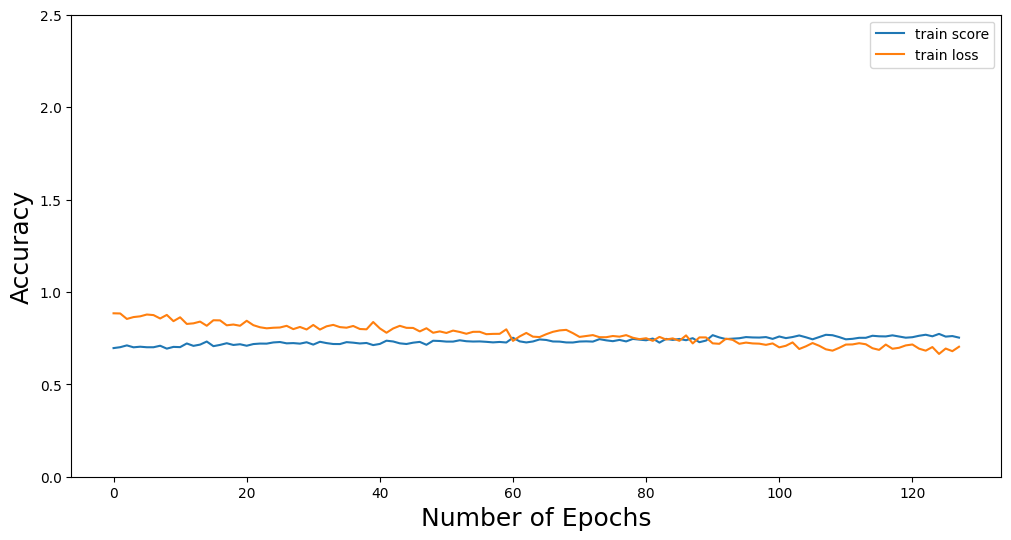

Train Data Shape: (2286, 300, 12)
Test Data Shape: (1132, 300, 12)


Model: "functional_35"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_35      │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_105 (Conv1D) │ (None, 293, 64)   │      6,208 │ input_layer_35[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_35    │ (None, 31, 64)    │          0 │ conv1d_105[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_175         │ (None, 31, 64)    │          0 │ max_pooling1d_35… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_175[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_35        │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │    134,721 │ time2_vec_35[0][… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_35[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_177         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_177[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_70 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_35[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_106 (Conv1D) │ (None, 31, 3)     │        198 │ add_70[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_178         │ (None, 31, 3)     │          0 │ conv1d_106[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_107 (Conv1D) │ (None, 31, 65)    │        260 │ dropout_178[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_107[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_71 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_70[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 65)        │          0 │ add_71[0][0]      │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_70 (Dense)    │ (None, 128)       │      8,448 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_179         │ (None, 128)       │          0 │ dense_70[0][0]    │
│ (Dropout)           │                   │            │                 

 Total params: 152,353 (595.13 KB)

 Trainable params: 152,225 (594.63 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 13s 291ms/step - accuracy: 0.0773 - loss: 2.8660
Epoch 2/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 184ms/step - accuracy: 0.1231 - loss: 2.6653
Epoch 3/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 244ms/step - accuracy: 0.1435 - loss: 2.5869
Epoch 4/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 208ms/step - accuracy: 0.2060 - loss: 2.4383
Epoch 5/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 212ms/step - accuracy: 0.2436 - loss: 2.3420
Epoch 6/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 243ms/step - accuracy: 0.2889 - loss: 2.1969
Epoch 7/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 181ms/step - accuracy: 0.3291 - loss: 2.1048
Epoch 8/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 211ms/step - accuracy: 0.3240 - loss: 2.0178
Epoch 9/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 193ms/step - accuracy: 0.3565 - loss: 1.9627
Epoch 10/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 201ms/step - accuracy: 0.3753 - loss: 1.9019
Epoch 11/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 167ms/step - accuracy: 0.3554 - loss: 1.9190
Epoch 12/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.9545 - loss: 0.1383
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 265ms/step - accuracy: 0.8049 - loss: 0.7239
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step
>#36: 
  train accuracy: 0.93351
  train loss    : 0.20399
  test accuracy: 0.75353
  test loss    : 0.92246

Accuracy: 0.75353 (+/-0.00000)
Loss: 0.92246 (+/-0.00000)


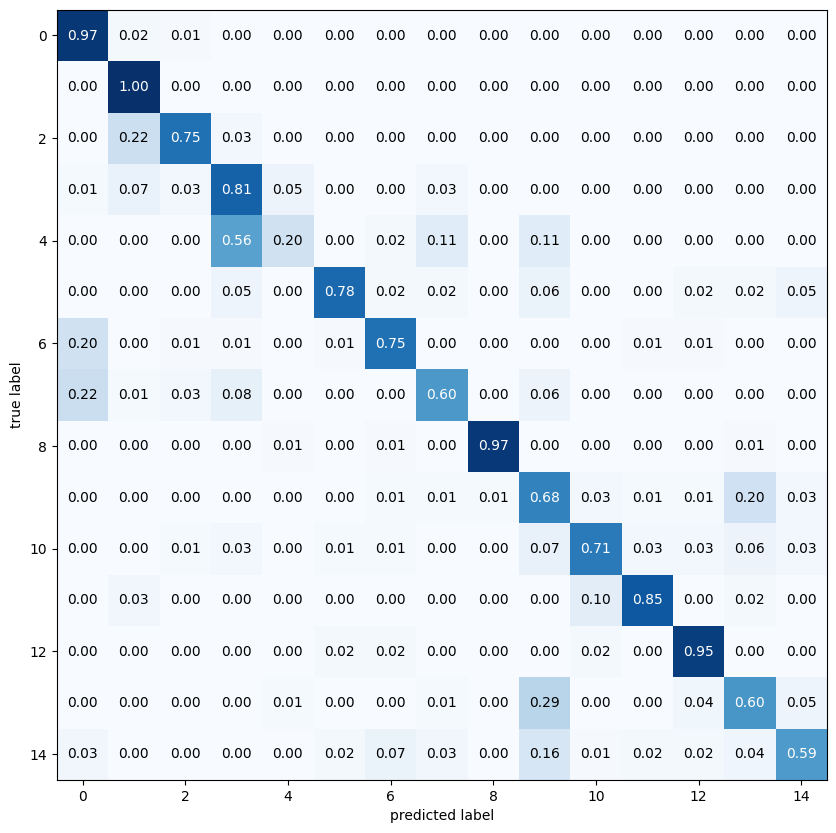

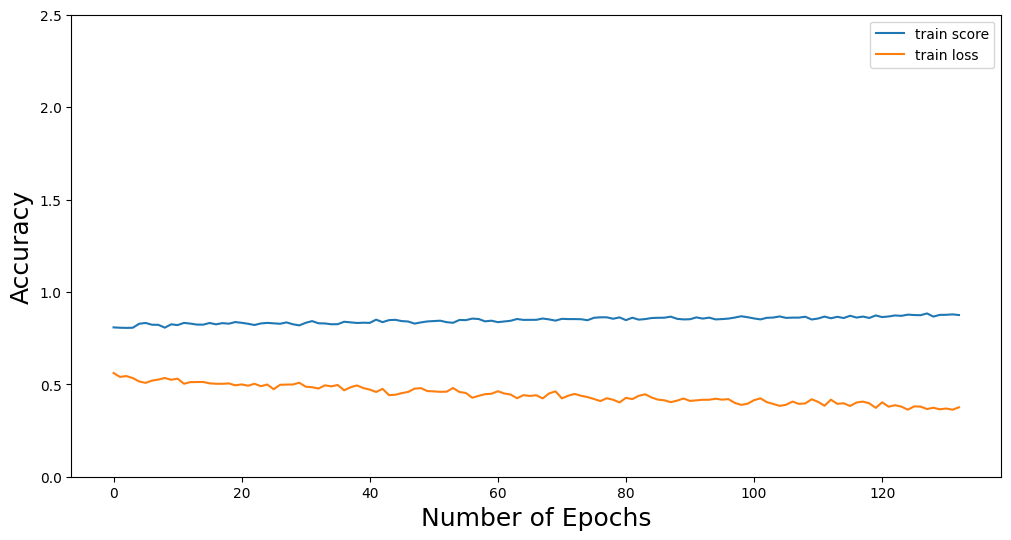

Train Data Shape: (2305, 300, 12)
Test Data Shape: (1152, 300, 12)


Model: "functional_36"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_36      │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_108 (Conv1D) │ (None, 293, 64)   │      6,208 │ input_layer_36[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_36    │ (None, 31, 64)    │          0 │ conv1d_108[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_180         │ (None, 31, 64)    │          0 │ max_pooling1d_36… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_180[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_36        │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │    134,721 │ time2_vec_36[0][… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_36[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_182         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_182[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_72 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_36[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_109 (Conv1D) │ (None, 31, 3)     │        198 │ add_72[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_183         │ (None, 31, 3)     │          0 │ conv1d_109[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_110 (Conv1D) │ (None, 31, 65)    │        260 │ dropout_183[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_110[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_73 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_72[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 65)        │          0 │ add_73[0][0]      │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_72 (Dense)    │ (None, 128)       │      8,448 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_184         │ (None, 128)       │          0 │ dense_72[0][0]    │
│ (Dropout)           │                   │            │                 

 Total params: 152,353 (595.13 KB)

 Trainable params: 152,225 (594.63 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/300
19/19 ━━━━━━━━━━━━━━━━━━━━ 13s 165ms/step - accuracy: 0.1015 - loss: 2.7350
Epoch 2/300
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 175ms/step - accuracy: 0.1623 - loss: 2.4930
Epoch 3/300
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 180ms/step - accuracy: 0.1948 - loss: 2.4204
Epoch 4/300
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 159ms/step - accuracy: 0.2260 - loss: 2.3224
Epoch 5/300
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 157ms/step - accuracy: 0.3009 - loss: 2.1389
Epoch 6/300
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 147ms/step - accuracy: 0.3305 - loss: 2.0156
Epoch 7/300
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 152ms/step - accuracy: 0.3472 - loss: 1.9478
Epoch 8/300
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 147ms/step - accuracy: 0.3431 - loss: 1.9123
Epoch 9/300
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 154ms/step - accuracy: 0.3848 - loss: 1.8098
Epoch 10/300
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 146ms/step - accuracy: 0.4014 - loss: 1.7355
Epoch 11/300
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 145ms/step - accuracy: 0.4438 - loss: 1.6527
Epoch 12/300
19/19 ━━━━━━━━━━━━━━━━━━━━ 

19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.9085 - loss: 0.2742
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8337 - loss: 0.4801
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
>#37: 
  train accuracy: 0.88764
  train loss    : 0.33030
  test accuracy: 0.77604
  test loss    : 0.64860

Accuracy: 0.77604 (+/-0.00000)
Loss: 0.64860 (+/-0.00000)


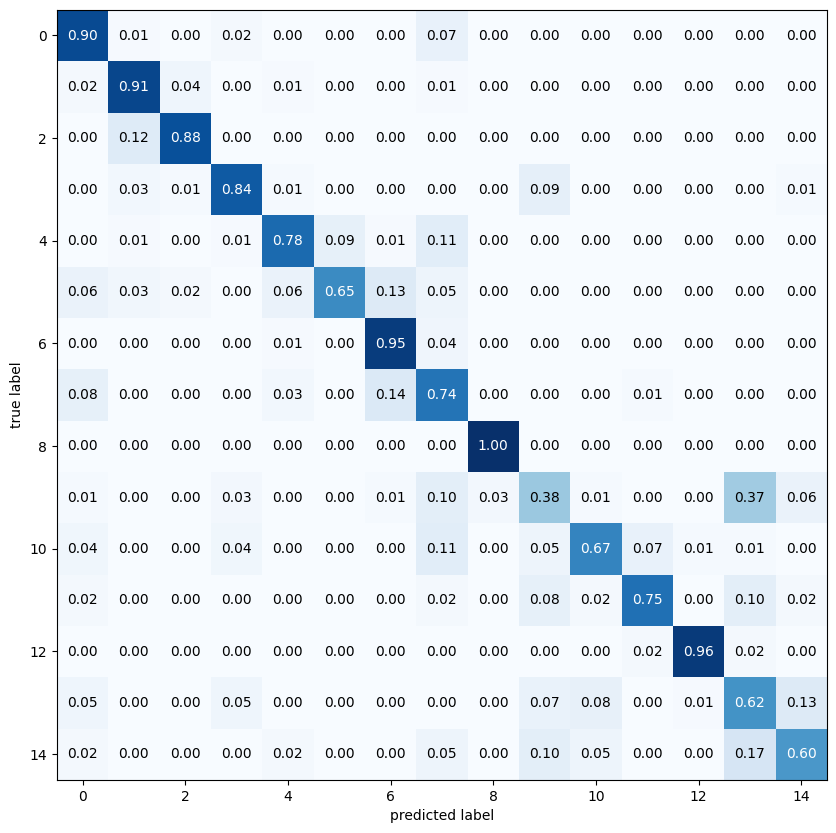

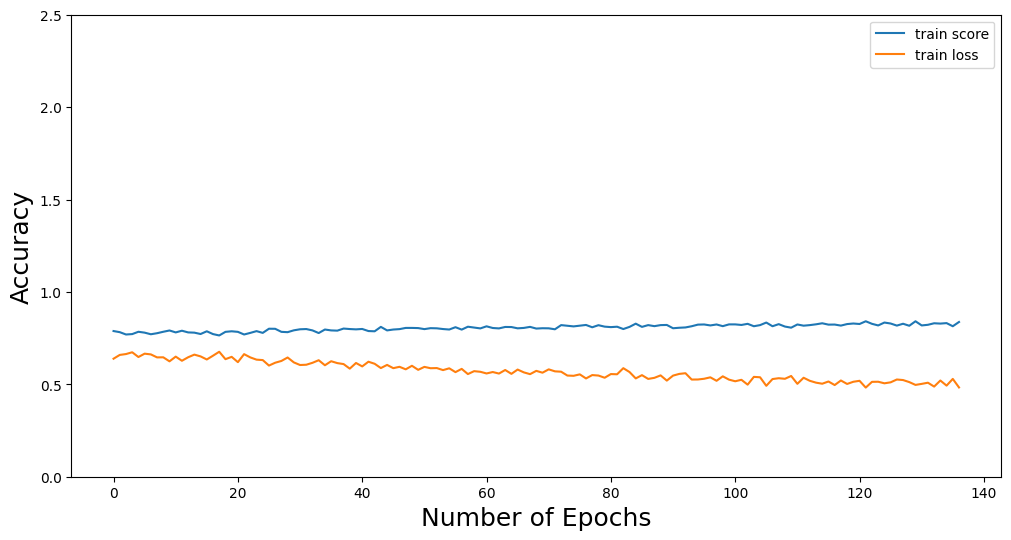

Train Data Shape: (2632, 300, 12)
Test Data Shape: (1315, 300, 12)


Model: "functional_37"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_37      │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_111 (Conv1D) │ (None, 293, 64)   │      6,208 │ input_layer_37[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_37    │ (None, 31, 64)    │          0 │ conv1d_111[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_185         │ (None, 31, 64)    │          0 │ max_pooling1d_37… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_185[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_37        │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │    134,721 │ time2_vec_37[0][… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_37[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_187         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_187[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_74 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_37[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_112 (Conv1D) │ (None, 31, 3)     │        198 │ add_74[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_188         │ (None, 31, 3)     │          0 │ conv1d_112[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_113 (Conv1D) │ (None, 31, 65)    │        260 │ dropout_188[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_113[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_75 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_74[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 65)        │          0 │ add_75[0][0]      │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_74 (Dense)    │ (None, 128)       │      8,448 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_189         │ (None, 128)       │          0 │ dense_74[0][0]    │
│ (Dropout)           │                   │            │                 

 Total params: 152,353 (595.13 KB)

 Trainable params: 152,225 (594.63 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 18s 351ms/step - accuracy: 0.0844 - loss: 2.8836
Epoch 2/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 268ms/step - accuracy: 0.1222 - loss: 2.5258
Epoch 3/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 228ms/step - accuracy: 0.1535 - loss: 2.4523
Epoch 4/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 206ms/step - accuracy: 0.2107 - loss: 2.3538
Epoch 5/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 204ms/step - accuracy: 0.2761 - loss: 2.2217
Epoch 6/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 183ms/step - accuracy: 0.3242 - loss: 2.0518
Epoch 7/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 190ms/step - accuracy: 0.3399 - loss: 1.9961
Epoch 8/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 178ms/step - accuracy: 0.3455 - loss: 1.9501
Epoch 9/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 147ms/step - accuracy: 0.3737 - loss: 1.8556
Epoch 10/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 132ms/step - accuracy: 0.4103 - loss: 1.7818
Epoch 11/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step - accuracy: 0.4281 - loss: 1.6800
Epoch 12/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 

21/21 ━━━━━━━━━━━━━━━━━━━━ 36s 274ms/step - accuracy: 0.8886 - loss: 0.3178
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 475ms/step - accuracy: 0.7624 - loss: 0.6614
42/42 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step
>#38: 
  train accuracy: 0.91641
  train loss    : 0.26216
  test accuracy: 0.79924
  test loss    : 0.63670

Accuracy: 0.79924 (+/-0.00000)
Loss: 0.63670 (+/-0.00000)


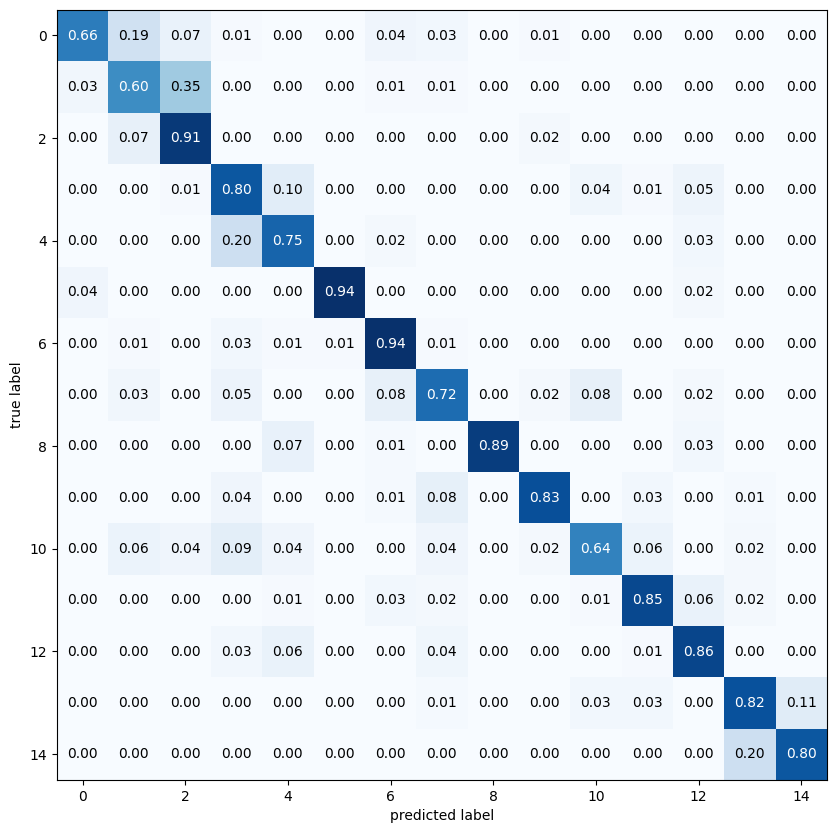

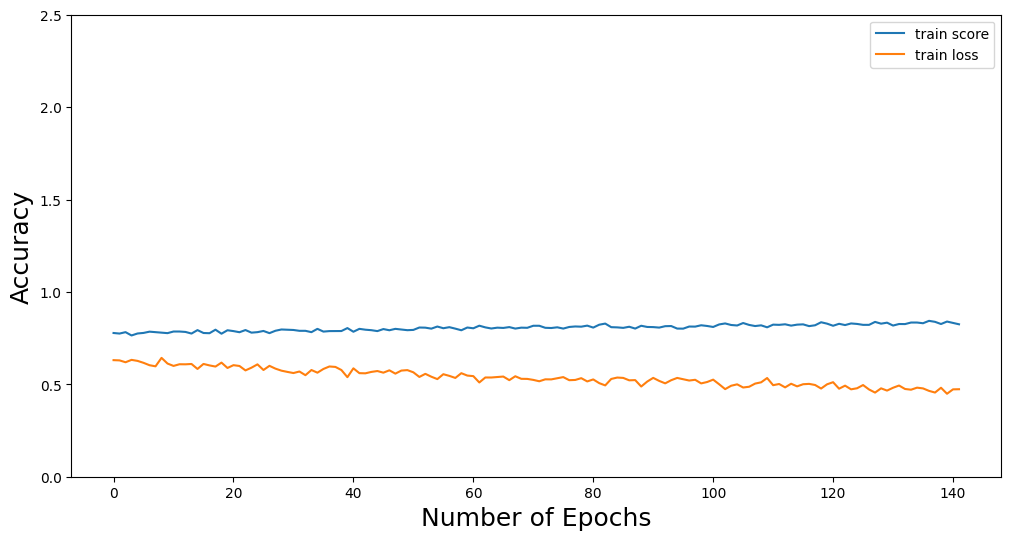

Train Data Shape: (3110, 300, 12)
Test Data Shape: (1545, 300, 12)


Model: "functional_38"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_38      │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_114 (Conv1D) │ (None, 293, 64)   │      6,208 │ input_layer_38[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_38    │ (None, 31, 64)    │          0 │ conv1d_114[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_190         │ (None, 31, 64)    │          0 │ max_pooling1d_38… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_190[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_38        │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │    134,721 │ time2_vec_38[0][… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_38[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_192         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_192[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_76 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_38[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_115 (Conv1D) │ (None, 31, 3)     │        198 │ add_76[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_193         │ (None, 31, 3)     │          0 │ conv1d_115[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_116 (Conv1D) │ (None, 31, 65)    │        260 │ dropout_193[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_116[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_77 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_76[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 65)        │          0 │ add_77[0][0]      │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_76 (Dense)    │ (None, 128)       │      8,448 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_194         │ (None, 128)       │          0 │ dense_76[0][0]    │
│ (Dropout)           │                   │            │                 

 Total params: 152,353 (595.13 KB)

 Trainable params: 152,225 (594.63 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 210s 400ms/step - accuracy: 0.0989 - loss: 2.7476
Epoch 2/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 234ms/step - accuracy: 0.1760 - loss: 2.5169
Epoch 3/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 173ms/step - accuracy: 0.2175 - loss: 2.4078
Epoch 4/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 182ms/step - accuracy: 0.2665 - loss: 2.2698
Epoch 5/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 161ms/step - accuracy: 0.3050 - loss: 2.1330
Epoch 6/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 145ms/step - accuracy: 0.3242 - loss: 2.0813
Epoch 7/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 162ms/step - accuracy: 0.3328 - loss: 2.0193
Epoch 8/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 149ms/step - accuracy: 0.3695 - loss: 1.8788
Epoch 9/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 130ms/step - accuracy: 0.3896 - loss: 1.8319
Epoch 10/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 156ms/step - accuracy: 0.3983 - loss: 1.7559
Epoch 11/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 152ms/step - accuracy: 0.4378 - loss: 1.6962
Epoch 12/300
25/25 ━━━━━━━━━━━━━━━━━━━━

25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 121ms/step - accuracy: 0.9472 - loss: 0.1862
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 249ms/step - accuracy: 0.7836 - loss: 0.6730
49/49 ━━━━━━━━━━━━━━━━━━━━ 8s 91ms/step
>#39: 
  train accuracy: 0.93730
  train loss    : 0.20462
  test accuracy: 0.74757
  test loss    : 0.76719

Accuracy: 0.74757 (+/-0.00000)
Loss: 0.76719 (+/-0.00000)


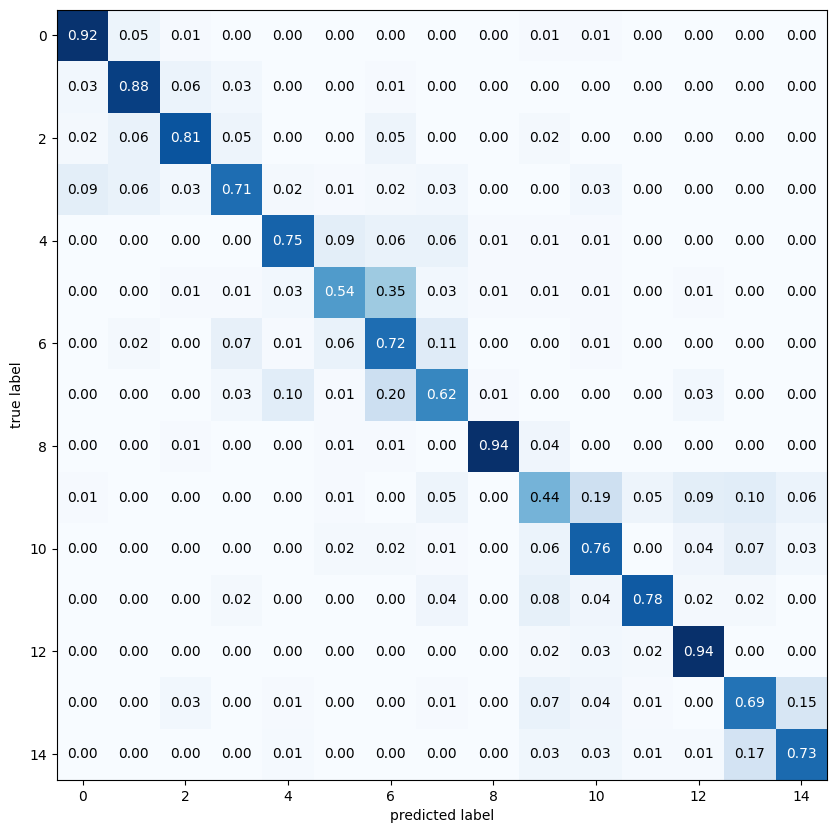

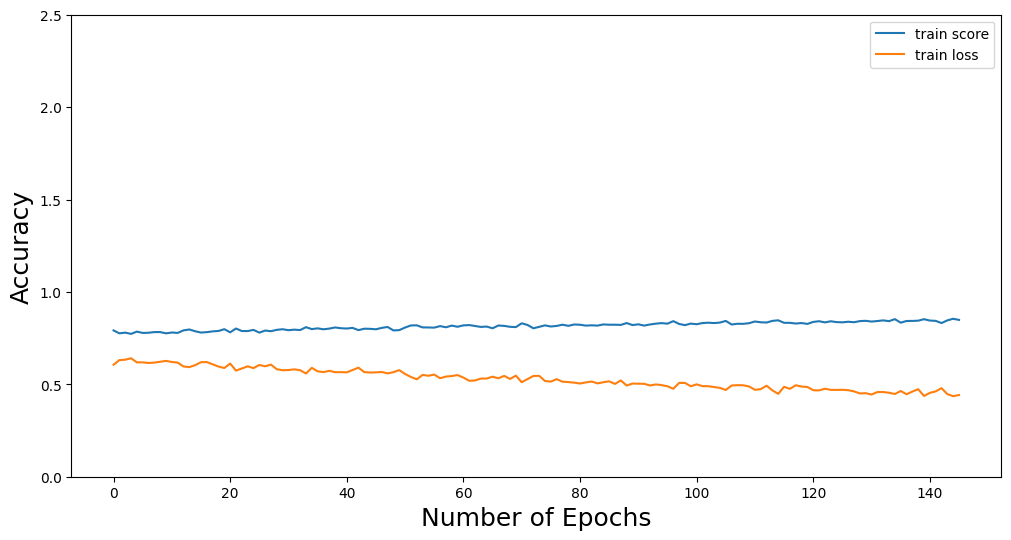

Train Data Shape: (1802, 300, 12)
Test Data Shape: (929, 300, 12)


Model: "functional_39"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_39      │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_117 (Conv1D) │ (None, 293, 64)   │      6,208 │ input_layer_39[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_39    │ (None, 31, 64)    │          0 │ conv1d_117[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_195         │ (None, 31, 64)    │          0 │ max_pooling1d_39… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 64)    │        256 │ dropout_195[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_39        │ (None, 31, 65)    │         67 │ batch_normalizat… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 65)    │    134,721 │ time2_vec_39[0][… │
│ (MultiHeadAttentio… │                   │            │ time2_vec_39[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_197         │ (None, 31, 65)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ dropout_197[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_78 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ time2_vec_39[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_118 (Conv1D) │ (None, 31, 3)     │        198 │ add_78[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_198         │ (None, 31, 3)     │          0 │ conv1d_118[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_119 (Conv1D) │ (None, 31, 65)    │        260 │ dropout_198[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 65)    │        130 │ conv1d_119[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_79 (Add)        │ (None, 31, 65)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_78[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 65)        │          0 │ add_79[0][0]      │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_78 (Dense)    │ (None, 128)       │      8,448 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_199         │ (None, 128)       │          0 │ dense_78[0][0]    │
│ (Dropout)           │                   │            │                 

 Total params: 152,353 (595.13 KB)

 Trainable params: 152,225 (594.63 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 81s 611ms/step - accuracy: 0.0721 - loss: 2.9485
Epoch 2/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 497ms/step - accuracy: 0.1513 - loss: 2.6247
Epoch 3/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 376ms/step - accuracy: 0.1376 - loss: 2.5983
Epoch 4/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 367ms/step - accuracy: 0.1616 - loss: 2.5394
Epoch 5/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 342ms/step - accuracy: 0.1862 - loss: 2.5228
Epoch 6/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 313ms/step - accuracy: 0.2044 - loss: 2.4748
Epoch 7/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 177ms/step - accuracy: 0.2320 - loss: 2.3970
Epoch 8/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 211ms/step - accuracy: 0.2621 - loss: 2.2809
Epoch 9/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 298ms/step - accuracy: 0.2405 - loss: 2.3149
Epoch 10/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 167ms/step - accuracy: 0.2922 - loss: 2.2189
Epoch 11/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 180ms/step - accuracy: 0.3279 - loss: 2.1069
Epoch 12/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 

15/15 ━━━━━━━━━━━━━━━━━━━━ 24s 259ms/step - accuracy: 0.9676 - loss: 0.0986
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.8573 - loss: 0.5776  
30/30 ━━━━━━━━━━━━━━━━━━━━ 31s 613ms/step
>#40: 
  train accuracy: 0.95782
  train loss    : 0.14555
  test accuracy: 0.81808
  test loss    : 0.72578

Accuracy: 0.81808 (+/-0.00000)
Loss: 0.72578 (+/-0.00000)


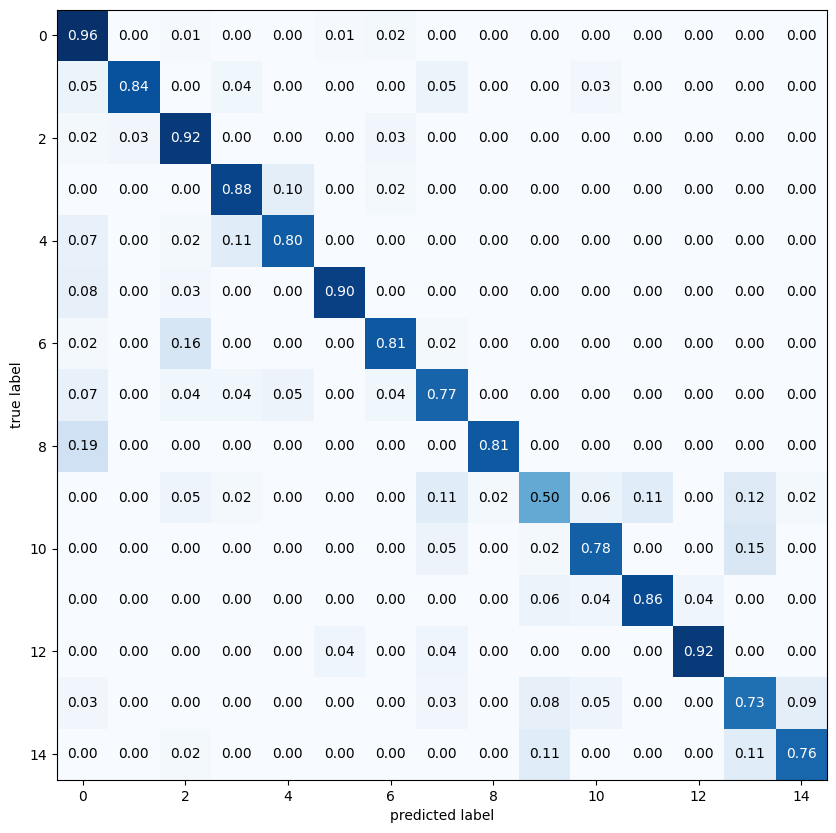

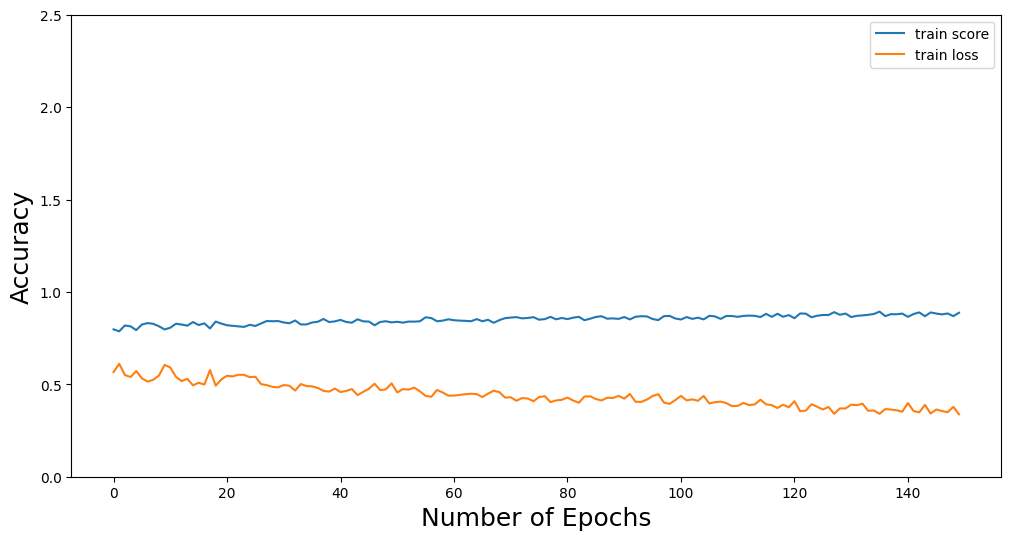

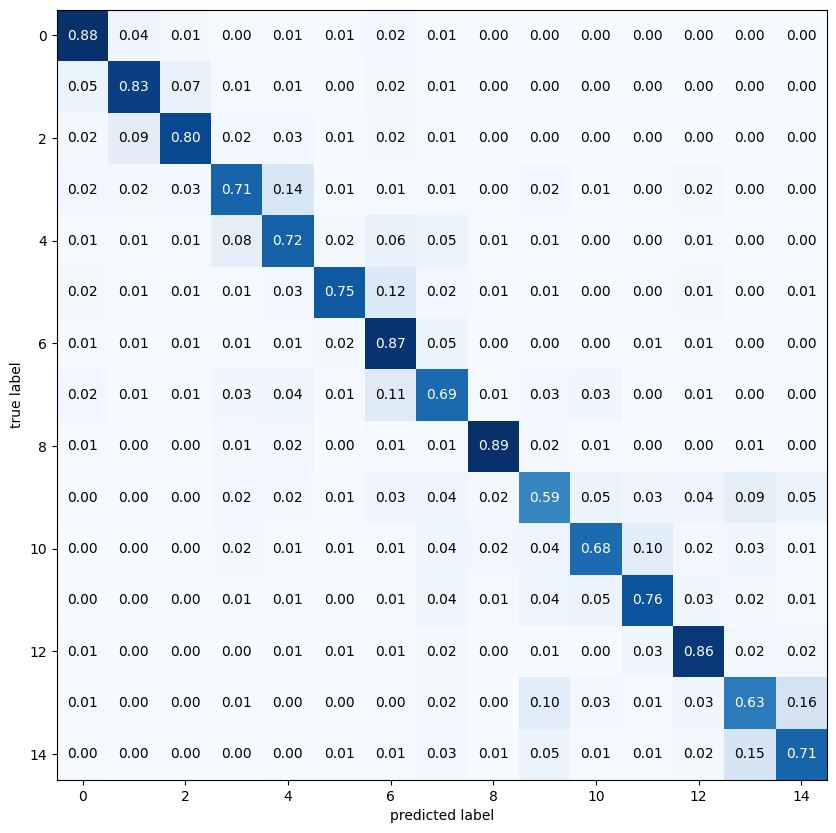

In [21]:

# Main
# ==============================================================================

globel_perd = []
globel_class = []

globel_perd1 = []
globel_class1 = []

# Create a workbook and add a worksheet.
workbook = xlsxwriter.Workbook(fr'D:\Transformer-Based-approach-for-hand-gesture-recognition-through-EMG-signals\DB2\results\v2\xlsx\Trans_rslt(21-40).xlsx')
worksheet1 = workbook.add_worksheet('Subjects informations')

# Start from the first cell. Rows and columns are zero indexed.
row = 0

worksheet1.write(row, 0, 'Subject')
worksheet1.write(row, 1, 'Train_time')
worksheet1.write(row, 2, 'Test_time')
worksheet1.write(row, 3, 'Train_acc')
worksheet1.write(row, 4, 'Train_loss')
worksheet1.write(row, 5, 'Test_acc')
worksheet1.write(row, 6, 'Test_loss')
worksheet1.write(row, 7, 'MCC')

history = History()
for i in range(21, 41):
    loss_train, score_train, loss_test, score_test, y_pred, testy, train_time, test_time = run_my_experiment(i)

    globel_perd.append(y_pred)
    globel_class.append(testy)

    globel_perd1.extend(y_pred)
    globel_class1.extend(testy)

    mcc = matthews_corrcoef(testy, y_pred)
    mat = confusion_matrix(testy, y_pred)

    cfm_plot, ax = plot_confusion_matrix(mat, figsize=(10, 10), show_normed=True, show_absolute=False)
    cfm_plot.savefig(fr'D:\Transformer-Based-approach-for-hand-gesture-recognition-through-EMG-signals\DB2\results\v2\confusion_matrix\S' + str(i) + 'trans_confusion_matrix.png')

    fig, axarr = plt.subplots(figsize=(12, 6), ncols=1)
    plot_renge = int(len(history.history['accuracy']) / i)
    global_renge = len(history.history['accuracy'])
    start_renge = global_renge - plot_renge
    axarr.plot(range(plot_renge), history.history['accuracy'][start_renge: global_renge], label='train score')
    axarr.plot(range(plot_renge), history.history['loss'][start_renge: global_renge], label='train loss')
    axarr.set_xlabel('Number of Epochs', fontsize=18)
    axarr.set_ylabel('Accuracy', fontsize=18)
    axarr.set_ylim([0, 2.5])
    plt.legend()
    plt.show()
    fig.savefig(fr'D:\Transformer-Based-approach-for-hand-gesture-recognition-through-EMG-signals\DB2\results\v2\graphs\S' + str(i) + 'trans_graphe.png')

    # Sheet informations
    worksheet1.write(i, 0, 'Sujet ' + str(i))
    worksheet1.write(i, 1, train_time)
    worksheet1.write(i, 2, test_time)
    worksheet1.write(i, 3, score_train)
    worksheet1.write(i, 4, loss_train)
    worksheet1.write(i, 5, score_test)
    worksheet1.write(i, 6, loss_test)
    worksheet1.write(i, 7, mcc)

workbook.close()

# Save prediction
new_data = {'pred_labels': globel_perd, 'class_labels': globel_class}
savemat(fr'D:\Transformer-Based-approach-for-hand-gesture-recognition-through-EMG-signals\DB2\results\v2\trans_global_predection.mat', new_data)

mat = confusion_matrix(globel_class1, globel_perd1)
cfm_plot, ax = plot_confusion_matrix(mat, figsize=(10, 10), show_normed=True, show_absolute=False)
cfm_plot.savefig(fr'D:\Transformer-Based-approach-for-hand-gesture-recognition-through-EMG-signals\DB2\results\v2\trans_global_confusion_matrix.png')